In this file, we focus on using ensemble score filter (EnSF) to calibrate the preditions from LSTM in Lorenz96 system. 

The LSTM model is assumed to be trained elsewhere and can make good next-step prediction. The LSTM model is trained with sufficient and accurate training data. 

In the data assimilation process, it is assumed that we can observe every dimension. 

# Package Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import tqdm
import functools
import pandas as pd
from functools import partial
import time
from scipy.integrate import odeint
import torch.utils.data as data
import copy
import math

In [2]:
# Lorenz96 system definition
def lorenz96(x, t, F = 8.0):
    """Lorenz 96 model with constant forcing"""
    return (np.roll(x, -1) - np.roll(x, 2)) * np.roll(x, 1) - x + F 

def initial_state_gen(N, lower_bound = 0, upper_bound = 1):
    """Generate a random initial state

    Args:
        N: Number of dimension
        lower_bound: Minimum value of the initial state
        upper_bound: Maximum value of the initial state

    Returns:
        An N-dimensional numpy array
    """
    if upper_bound <= lower_bound:
        return np.ones(N)
    return np.random.uniform(lower_bound, upper_bound, N)

def lorenz96_solver(initial_state, terminal_time, time_step, F = 8.0):
    """Use odeint to solve a lorenz96 model

    Args:
        initial_state: initial state of the lorenz96 model
        terminal_time: terminal time of the approximation
        time_step: number of time steps of the approximation
        F: constant forcing of lorenz96 model

    Returns:
        t: time steps
        sol: partical state at each time step
    """
    t = np.arange(0.0, terminal_time, time_step)
    sol = odeint(lorenz96, initial_state, t)
    return t, sol

def create_sequences(data, seq_len):
    """Create training input and output sequences

    Args:
        data: training dataset
        seq_len: LSTM sequence length

    Returns:
        Training input, training output
    """
    X, y = [], []
    for i in range(data.shape[0] - seq_len):
        X.append(data[i:i+seq_len, :])
        y.append(data[i+seq_len, :])
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

def create_data(data, LSTM_seq_len, device):
    """Send data to device. 

    Args: 
        data: training dataset
        LSTM_seq_len: LSTM sequence length
        device: device

    Returns: 
        Training data input, training data output. 
    """
    data_input, data_output = create_sequences(data, LSTM_seq_len)
    data_input = data_input.to(device)
    #data_input = data_input.transpose(-2,-1).to(device)
    data_output = data_output.to(device)
    return data_input, data_output

class LSTMModel(nn.Module):
    """LSTM model defined. 
    """
    def __init__(self, input_dim=3, output_dim=3, hidden_dim=128, num_layers=5):
        """Initialize LSTM

        Args: 
            input_dim: input dimension
            output_dim: output dimension
            hidden_dim: hidden dimension
            num_layers: number of hidden layers
        """
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        """Forward

        Args: 
            x: input data
        """
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden)

def training_LSTM(model, epochs, optimizer, loss_fn, data_input, data_output, batch_size = 128):
    """LSTM model training

    Args: 
        model: LSTM model
        epochs: epochs
        optimizer: optimizer, SGD or ADAM
        loss_fn: loss function, MSE
        data_input: input data
        data_output: label
        batch_size: batch size
    """
    loader = data.DataLoader(data.TensorDataset(data_input, data_output), shuffle=True, batch_size = batch_size)
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in loader:  
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        if (epoch + 1) % 250 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")


def training_LSTM_main(initial_state, x_dim, time_step, terminal_time, LSTM_seq_len, model, epochs, optimizer, loss_fn, batch_size = 128, F = 8.0, device = 'cpu'):
    """Main function of LSTM training. 

    Args: 
        initial_state: initial state of the Lorenz96 system
        x_dim: dimension of the Lorenz96 system
        time_step: dt
        terminal_time: terminal time for the data assimilation process
        LSTM_seq_len: LSTM sequence length
        model: LSTM model
        epochs: epochs
        optimizer: optimizer, SGD or ADAM
        loss_fn: loss function, MSE
        batch_size: batch size
        F: forcing constant in the Lorenz96 system
        device: device
    """
    t, sol = lorenz96_solver(initial_state, terminal_time, time_step, F)
    data_input, data_output = create_data(sol, LSTM_seq_len, device)
    #current = time.time()
    training_LSTM(model, epochs, optimizer, loss_fn, data_input, data_output, batch_size)
    #print(f"Training time: {time.time() - current}s")

def training_LSTM_inaccurate(initial_state, x_dim, time_step, terminal_time, LSTM_seq_len, model, epochs, optimizer, loss_fn, noise_std = 1, batch_size = 128, F = 8.0, device = 'cpu'):
    """Main function of LSTM training with inaccurate training data. 

    Args: 
        initial_state: initial state of the Lorenz96 system
        x_dim: dimension of the Lorenz96 system
        time_step: dt
        terminal_time: terminal time for the data assimilation process
        LSTM_seq_len: LSTM sequence length
        model: LSTM model
        epochs: epochs
        optimizer: optimizer, SGD or ADAM
        loss_fn: loss function, MSE
        noise_std: standard deviation of the noise
        batch_size: batch size
        F: forcing constant in the Lorenz96 system
        device: device
    """
    t, sol = lorenz96_solver(initial_state, terminal_time, time_step, F)
    data_input, data_output = create_data(sol, LSTM_seq_len, device)
    data_output = data_output + torch.randn_like(data_output) * noise_std
    training_LSTM(model, epochs, optimizer, loss_fn, data_input, data_output, batch_size)

def LSTM_plotting(initial_state, x_dim, time_step, terminal_time, LSTM_seq_len, model, F = 8.0, device = 'cpu'):
    """Plot the single-step prediction of the LSTM model using true states. 

    Args: 
        initial_state: initial state of the Lorenz96 system
        x_dim: dimension of the Lorenz96 system
        time_step: dt
        terminal_time: terminal time for the data assimilation process
        LSTM_seq_len: LSTM sequence length
        model: LSTM model
        F: forcing constant in the Lorenz96 system
        device: device
    """
    t, sol = lorenz96_solver(initial_state, terminal_time, time_step, F)
    data_input, data_output = create_data(sol, LSTM_seq_len, device)
    model.eval()
    with torch.no_grad():
        predictions = model(data_input).cpu().numpy()

    for i in range(dim_x):
        if_plot = np.random.randint(2)
        if if_plot:
            plt.plot(t[LSTM_seq_len: ], sol[LSTM_seq_len: , i], label = 'dim ' + str(i + 1), color = 'blue')
            plt.plot(t[LSTM_seq_len: ], predictions[:, i],  label = 'prediction', color = 'red')
            plt.legend(loc = 'upper right')
            plt.show()

def testing_dataset_MSE(initial_state, x_dim, time_step, terminal_time, LSTM_seq_len, model, F = 8.0, device = 'cpu'):
    """Compute the MSE

    Args: 
        initial_state: initial state of the Lorenz96 system
        x_dim: dimension of the Lorenz96 system
        time_step: dt
        terminal_time: terminal time for the data assimilation process
        LSTM_seq_len: LSTM sequence length
        model: LSTM model
        F: forcing constant in the Lorenz96 system
        device: device

    Returns: 
        MSE values. 
    """
    t, sol = lorenz96_solver(initial_state, terminal_time, time_step, F)
    data_input, data_output = create_data(sol, LSTM_seq_len, device)
    model.eval()
    with torch.no_grad():
        predictions = model(data_input).cpu()

    return loss_fn(predictions, torch.Tensor(sol[LSTM_seq_len:, :]))

# Defining a LSTM model

In [3]:
dim_x = 20                                                           # Dimension of the Lorenz96 system is 20
F = 8.0                                                              # Forcing constant in the Lorenz96 system is 8
device = 'cuda' if torch.cuda.is_available() else 'cpu'              # Use GPU if available
model = LSTMModel(input_dim = dim_x, output_dim = dim_x).to(device)  # Define a LSTM model
loss_fn = nn.MSELoss().to(device)                                    # Loss function is MSE
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)            # Adam optimizer
initial_state = np.ones(dim_x) * 8.0                                 # Initial States, [1, 1, 1, ..., 1, 1]
initial_state[0] += 0.5                                              # Perturbed the first state
total_data_size = 2500                                               # Total time steps
terminal_time = 10                                                   # Terminal time of the data assimilation process
time_step = terminal_time / total_data_size                          # Time step size = 10 / 2500
LSTM_seq_len = 20                                                    # LSTM sequence length
EPOCHS = 200                                                         # Epochs
batch_size = 128                                                     # Batch size
device

'cuda'

In [4]:
model.load_state_dict(torch.load('LSTM_Lorenz96_EnSF_accurate_1500.pth'))  # Load a trained LSTM model

<All keys matched successfully>

In [5]:
# Testing the LSTM single-step prediction error size
model_inher = testing_dataset_MSE(initial_state_gen(dim_x, 7, 9), dim_x, time_step, terminal_time, LSTM_seq_len, model, F, device)
# Repeat it for 100 times
for _ in range(99):
    model_inher = model_inher + \
                  testing_dataset_MSE(initial_state_gen(dim_x, 7, 9), dim_x, time_step, terminal_time, LSTM_seq_len, model, F, device)

In [6]:
# Average over 100 times
model_inher = float(model_inher.detach().numpy()) / 100
model_inher, device

(0.0958487606048584, 'cuda')

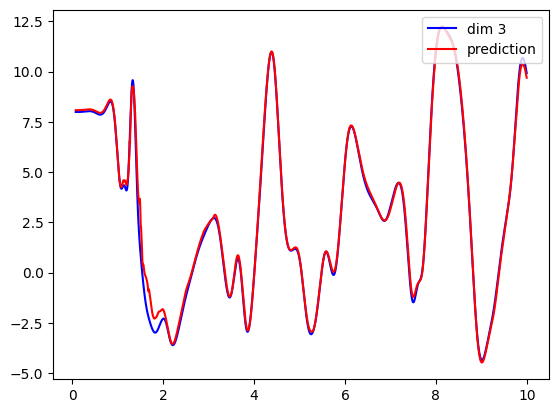

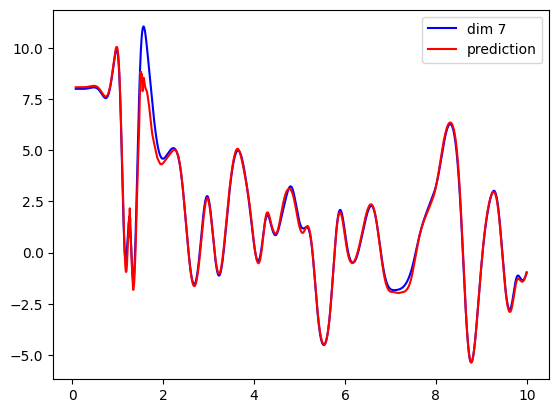

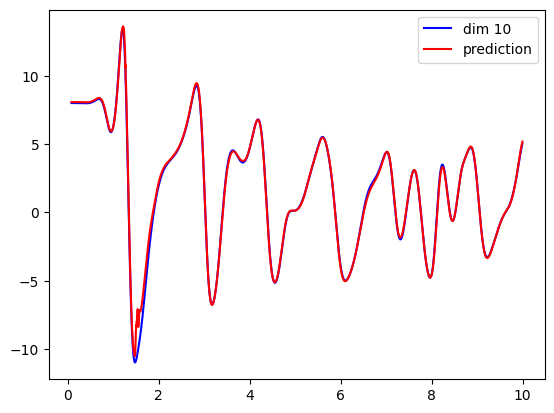

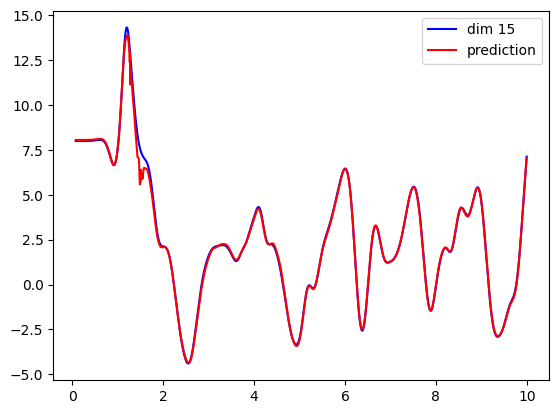

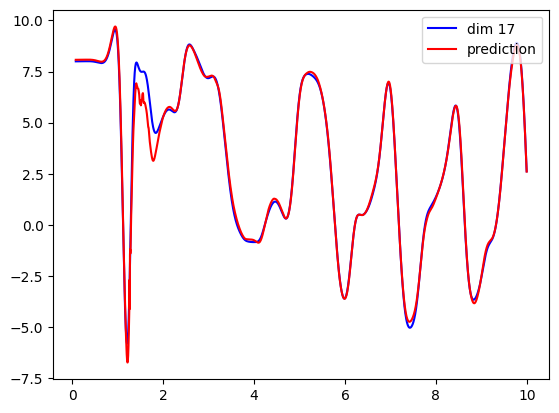

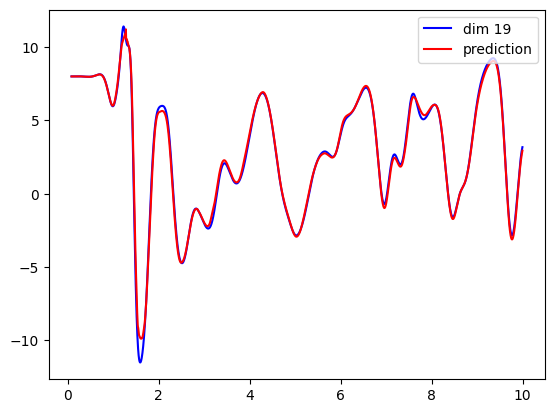

In [7]:
# Plot the single-step prediction of a Lorenz96 system. 
initial_state = np.ones(dim_x) * 8.0
initial_state[0] += 0.01
LSTM_plotting(initial_state, dim_x, time_step, terminal_time, LSTM_seq_len, model, F, device)

# Data Assimilation with EnSF

obs_gap = 20 \
consecutive_obs = 15 \
obs_sigma = 0.01 \
obs_range = math.atan(15) \
initial_state_std = 1 \
ensemble_size = 100 \
forward_error = 0.1 \
obs_function = atan 

In [8]:
# Import EnSF
from diffusion import *
model.eval()

LSTMModel(
  (lstm): LSTM(20, 128, num_layers=5, batch_first=True)
  (fc): Linear(in_features=128, out_features=20, bias=True)
)

In [9]:
# Nonlinear observation function
obs_fun = lambda x: torch.atan(x)
def atan_score_ana(xt, obs_value):
    score_x = -(torch.atan(xt) - obs_value)/obs_sigma**2 * (1./(1. + xt**2))
    #score_x = -(xt - obs_value) / obs_sigma ** 2
    return score_x

In [10]:
#initial_state = [F for i in range(dim_x)]
#initial_state[0] += 0.01
t = np.linspace(0, terminal_time, total_data_size, endpoint = False)        # Discretize in time
sol = np.loadtxt("lorenz96_20.txt", dtype = 'float64')                      # Load a saved Lorenz96 system
test_data_ensf = torch.tensor(sol[LSTM_seq_len: , :], dtype = torch.float32).to(device)

In [11]:
seed = 42
clip_tol = 50
default_dtype = torch.float32
obs_gap = 20           # Observation Gap
consecutive_obs = 15  # Consecutive observations
initial_state_std = 1 # Standard deviation of the initial states
obs_sigma = 0.01      # Standard deviation of the observation
obs_range = math.atan(15)       # Maximum and minimum value of the observation
dt = 0.004                      # dt
N_step = len(test_data_ensf)    # Number of data assimilation steps
# getup filter param
def damp_fn(t):
    """Define the damping function

    Args: 
        t: pseudo time
    """
    return (1-t) * 1.0

method_id = 0
ensemble_size=100     # Number of ensembles used
Nt_SDE = 500
forward_error = 0.1   # Standard deviation of the forward error
gm_var_ratio = forward_error ** 2 + model_inher  # Forward error and the model error
inflation = 1
eps_a = 1
eps_b = 0
solver = 'SDE_euler'
# EnSF
ns = NoiseSchedule(ns_type='linear', eps_a=eps_a, eps_b=eps_b)
dm = ReverseSampler(noise_schedule=ns)
score_rep = ScoreRep(dm=dm, dim_x=dim_x, obs_model=obs_fun, obs_sigma=obs_sigma)
# Store the first 20 states in the queue
x_state_queue = torch.from_numpy(sol[: LSTM_seq_len, :].reshape([1, LSTM_seq_len, dim_x])).to(torch.float32).to(device)

# Repeat it for all ensembles
for i in range(ensemble_size - 1):
    x_state_queue=torch.cat((x_state_queue, torch.from_numpy(sol[: LSTM_seq_len, :].reshape([1, LSTM_seq_len, dim_x])).to(torch.float32).to(device)), dim=0)    # info container var

# Add noise to ensembles
x_state_queue = x_state_queue + torch.randn_like(x_state_queue) * initial_state_std

rmse_all_step = []
mse_all_step = []
rmse_post = []
x_states=[]
x_ests=[]
do_obs = 0
x_state_std = []

In [12]:
for i in range(LSTM_seq_len, LSTM_seq_len + N_step): 
    if i % 100 == 0: 
        print(f"Step {i}")
    ###############################################################
    # prediction step
    ###############################################################
    # true state forward in time
    state_true = test_data_ensf[i - LSTM_seq_len]

    # Drop the first state in the queue and add the current
    if i != LSTM_seq_len:
        x_state_queue = torch.cat((x_state_queue[:, 1: , :], x_state.unsqueeze(1)), dim=1)

    # Forward
    x_state = model(x_state_queue).detach()                          # Now it contains the predicted state of time t+1
    x_state = x_state + torch.randn_like(x_state) * forward_error    # Add forward error to it. 

    # state clip
    x_state = torch.clip(x_state, min=-clip_tol, max=clip_tol)       # Clip
    ###############################################################

    # get forecast info
    x_est = torch.mean(x_state, dim=0)
    rmse_temp_1 = torch.sqrt(torch.mean((x_est - state_true) ** 2)).item()
    rmse_all_step.append([i, rmse_temp_1])                           # RMSE before doing data assimilation

    x_states.append(x_est.cpu().detach().numpy())                    # Store the state
    x_state_std.append(x_state.std(dim = 0).cpu().detach().numpy())
    mse_all_step.append(loss_fn(x_est.to(device), state_true).cpu().numpy())
    # divergence break
    if rmse_temp_1 > 1000 or np.isnan(rmse_temp_1):
        print('rmse:', rmse_temp_1)
        print('break!')
        break
        
    ###############################################################
    # update step
    ###############################################################
    if (i) % obs_gap == 0:
        do_obs = consecutive_obs
    if do_obs:
        do_obs = do_obs - 1
        # get obs
        obs_value = obs_fun(state_true) + obs_sigma*torch.randn_like(state_true)    # Get observation with noise
        obs_value = torch.clamp(obs_value, min = -obs_range, max = obs_range)       # Clip

        t1 = time.time()
        # update step
        # EnSF
        ###############################################################
        x_prior = x_state.clone()
        # GMM
        # ensemble
        score_prior_gm_fn = functools.partial(score_rep.score_gaussian_diffusion_diag,
                                              prior_mean=x_prior, prior_var=gm_var_ratio)
        # likelihood score
        score_likelihood_fn = lambda xt, t: atan_score_ana(xt, obs_value=obs_value) * damp_fn(t)
        post_score_fn = functools.partial(post_score, score_prior=score_prior_gm_fn, score_likelihood=score_likelihood_fn,
                                          score_max=1000)
        # terminal noise
        x_T = torch.randn(ensemble_size, dim_x, device=device, dtype=default_dtype)
        x_state = dm.sample_gen(x_T=x_T, score_fn=post_score_fn, Nt=Nt_SDE, solver_type=solver)
        ###############################################################
        t2 = time.time()
        ###############################################################
        # get info
        # rmse
        x_est = torch.mean(x_state, dim=0)
        x_states[-1] = x_est.cpu().detach().numpy()
        x_ests.append(x_est.cpu().detach().numpy())
        rmse_temp_2 = torch.sqrt(torch.mean((x_est - state_true) ** 2)).item()
        x_state_std[-1] = x_state.std(dim = 0).cpu().detach().numpy()
        mse_all_step[-1] = loss_fn(x_est.to(device), state_true).cpu().numpy()
        if i % 500 == 0:
            print(f'step {i} DA:')
            print(f'\t before DA: {rmse_temp_1:.4f}')
            print(f'\t  after DA: {rmse_temp_2:.4f}')
            print(f'\t      time: {t2 - t1:.4f}')
        rmse_all_step[-1] = [i, rmse_temp_2]
        rmse_post.append([i, rmse_temp_2])
rmse_all_step = np.array(rmse_all_step)
rmse_post = np.array(rmse_post)

Step 100
Step 200
Step 300
Step 400
Step 500
step 500 DA:
	 before DA: 0.9461
	  after DA: 0.3161
	      time: 0.4016
Step 600
Step 700
Step 800
Step 900
Step 1000
step 1000 DA:
	 before DA: 0.8390
	  after DA: 0.4695
	      time: 0.4027
Step 1100
Step 1200
Step 1300
Step 1400
Step 1500
step 1500 DA:
	 before DA: 0.5976
	  after DA: 0.2150
	      time: 0.4001
Step 1600
Step 1700
Step 1800
Step 1900
Step 2000
step 2000 DA:
	 before DA: 1.2709
	  after DA: 0.5140
	      time: 0.4066
Step 2100
Step 2200
Step 2300
Step 2400


# Plotting

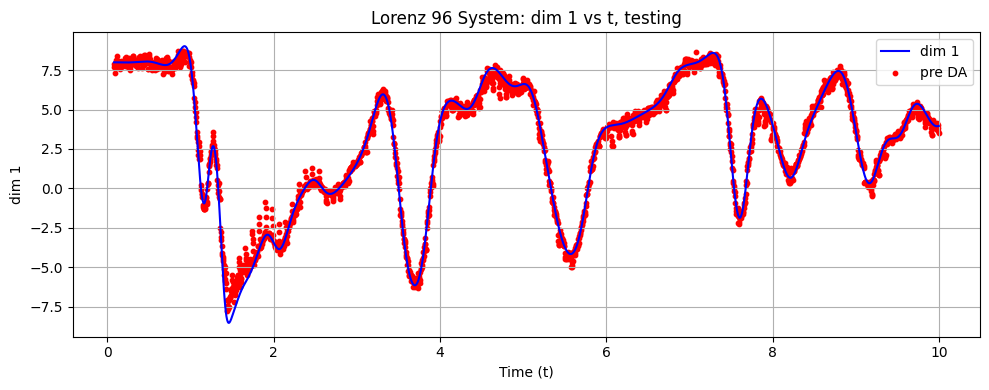

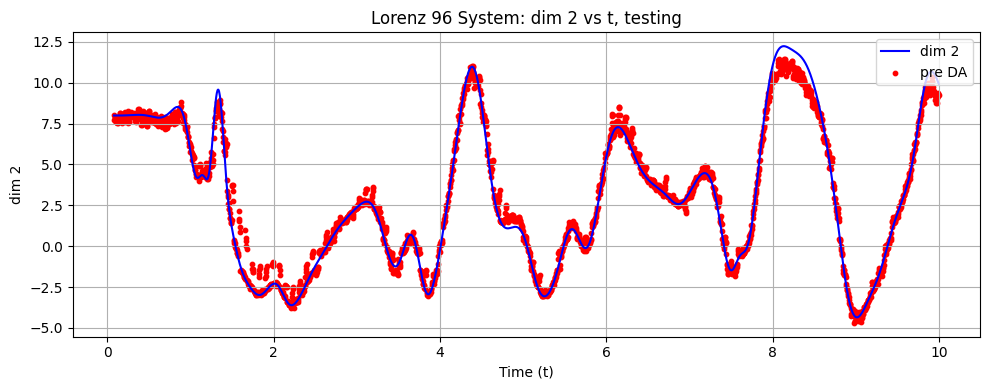

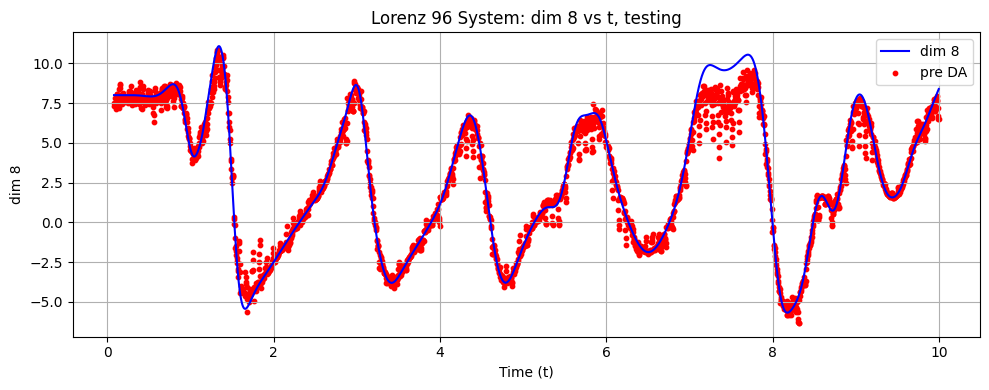

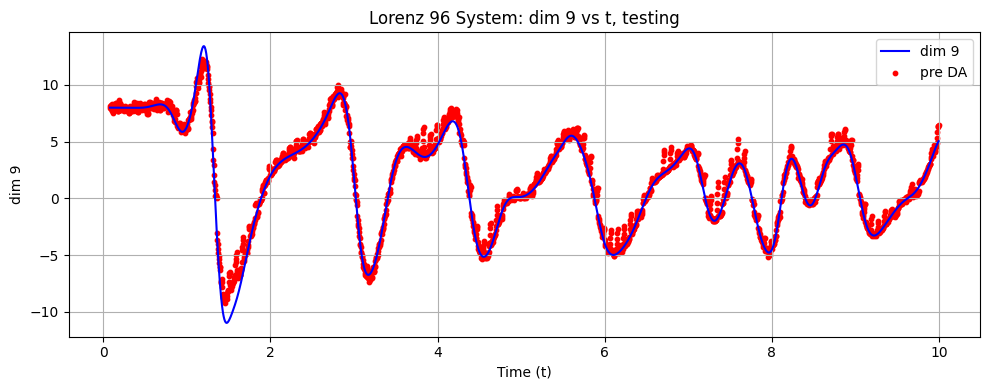

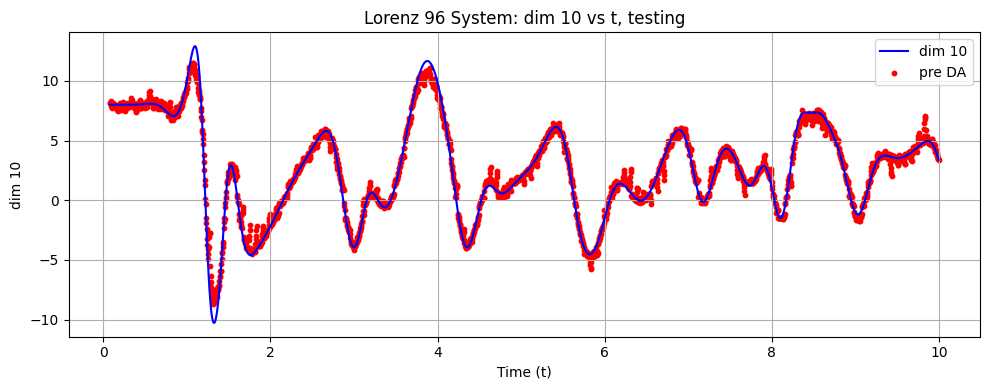

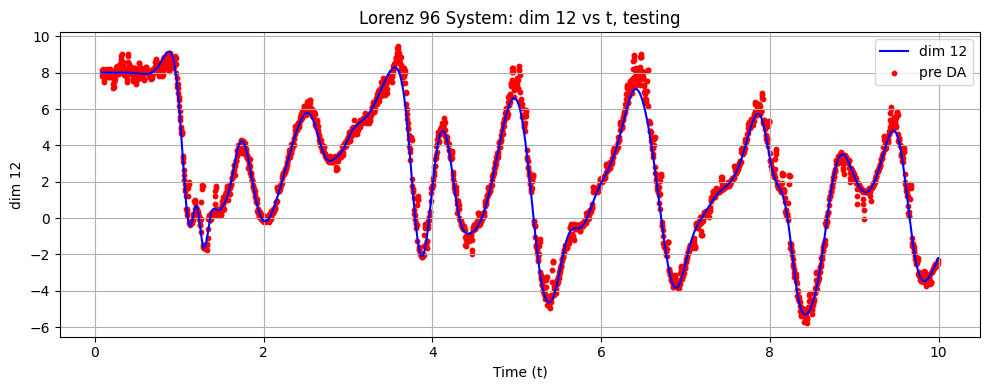

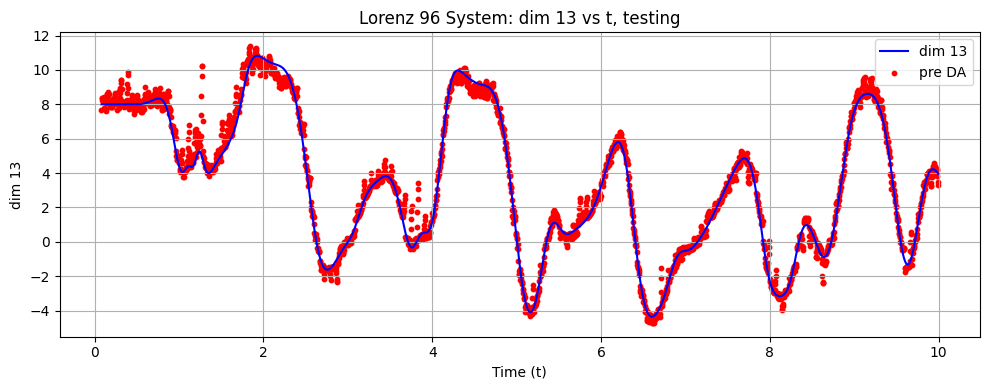

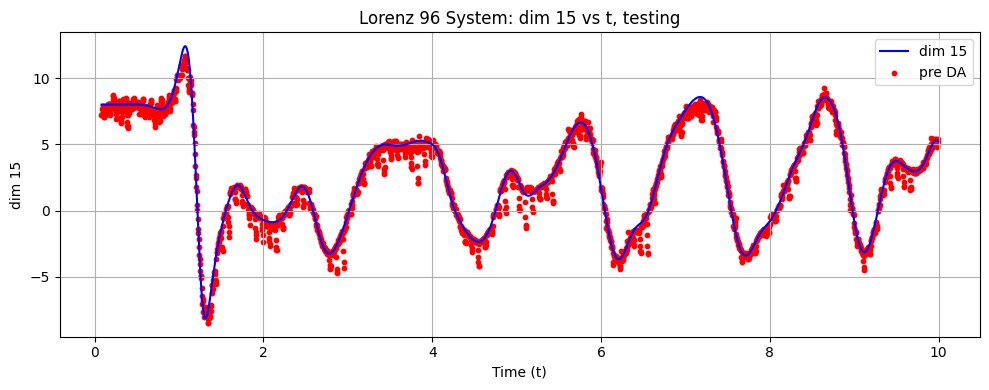

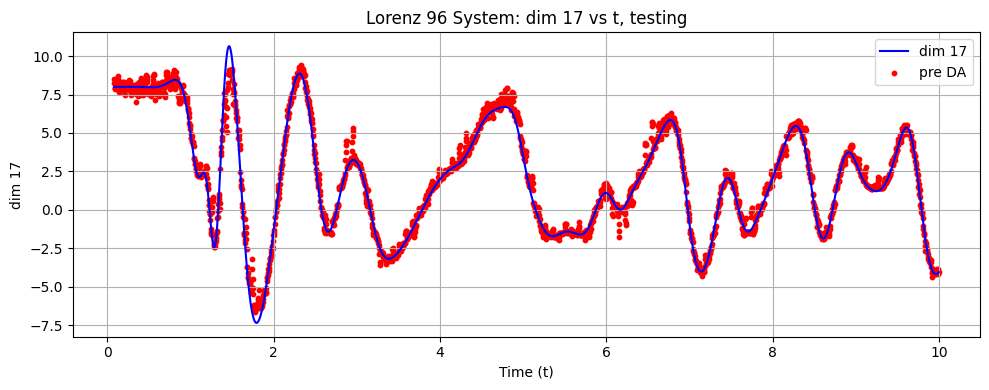

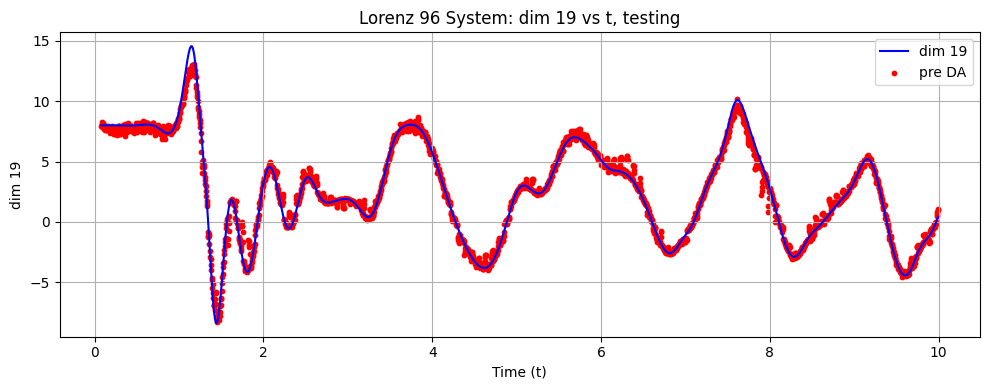

In [13]:
rr = np.array(x_states)
for i in range(dim_x):
    if_plot = np.random.randint(2)
    if if_plot:
        plt.figure(figsize = (10, 4))
        plt.plot(t[LSTM_seq_len: ], sol[LSTM_seq_len: , i], label = 'dim ' + str(i), color = 'blue')
        plt.scatter(t[LSTM_seq_len: ], rr[:, i], label = 'pre DA', color = 'red', s = 10)
        plt.title("Lorenz 96 System: dim " + str(i) + " vs t, testing")
        plt.xlabel("Time (t)")
        plt.ylabel("dim " + str(i))
        plt.grid(True)
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.show()

In [14]:
temp_input, temp_output = create_data(sol, LSTM_seq_len, device)

In [15]:
fifo_x = []
for i in range(0, sol.shape[0] - LSTM_seq_len):
    fifo_x.append(sol[i: i + 20, :])
fifo_x = np.array(fifo_x, dtype = np.float32)
fifo_x = torch.from_numpy(fifo_x).to(device)
fifo_y = model(fifo_x).cpu().detach().numpy()

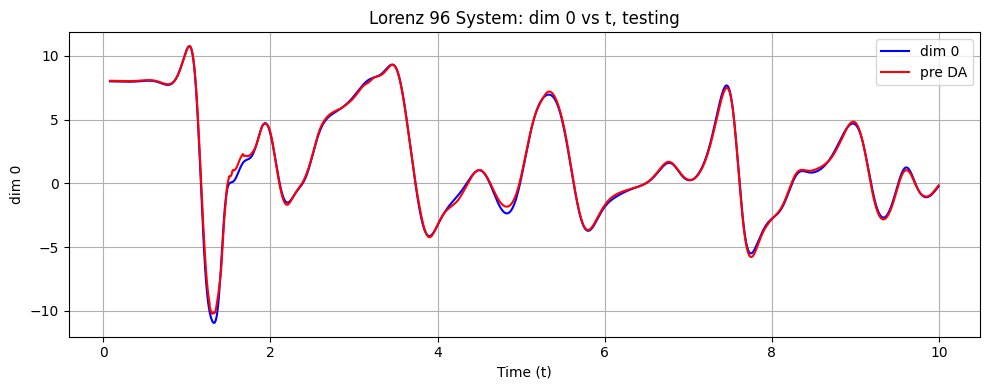

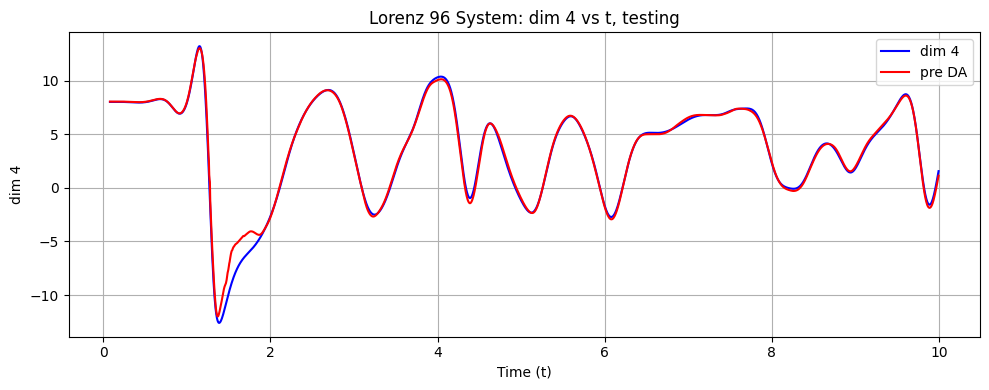

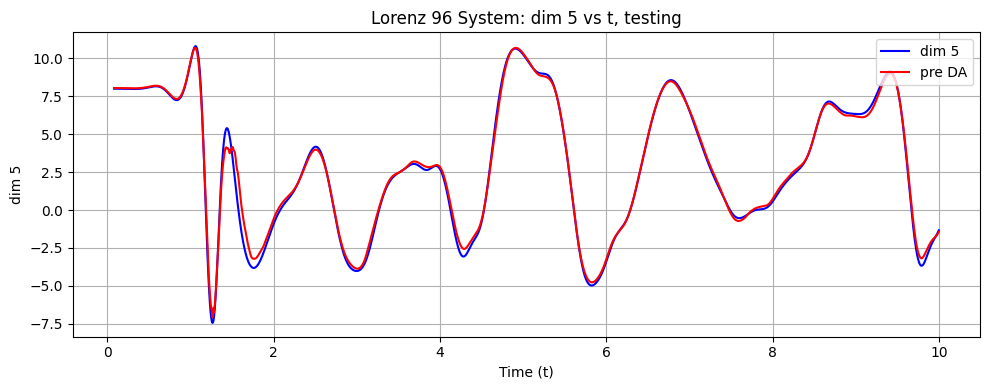

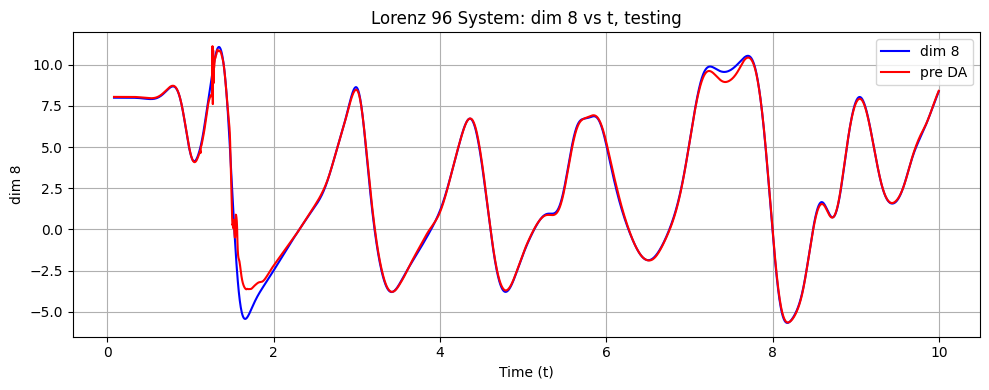

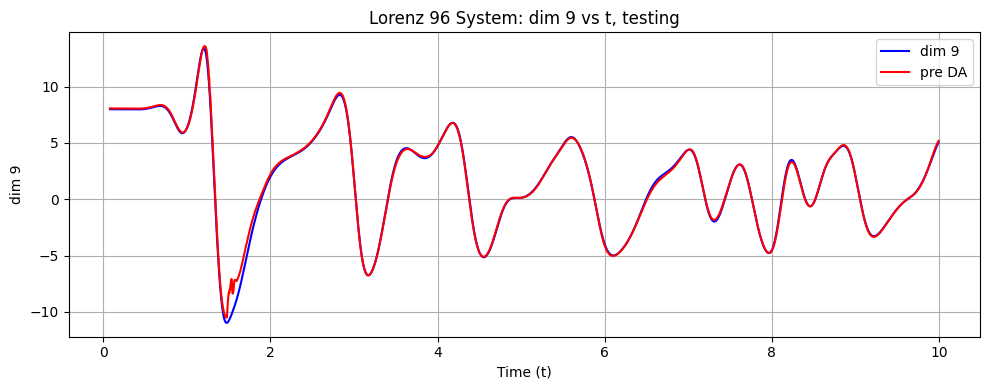

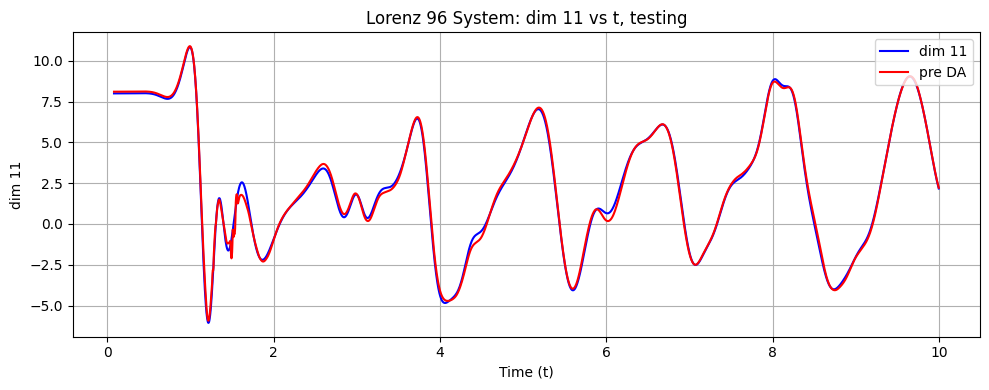

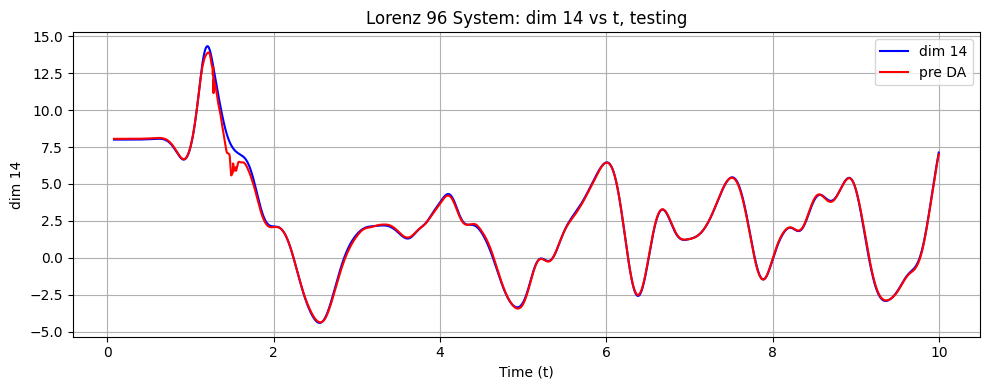

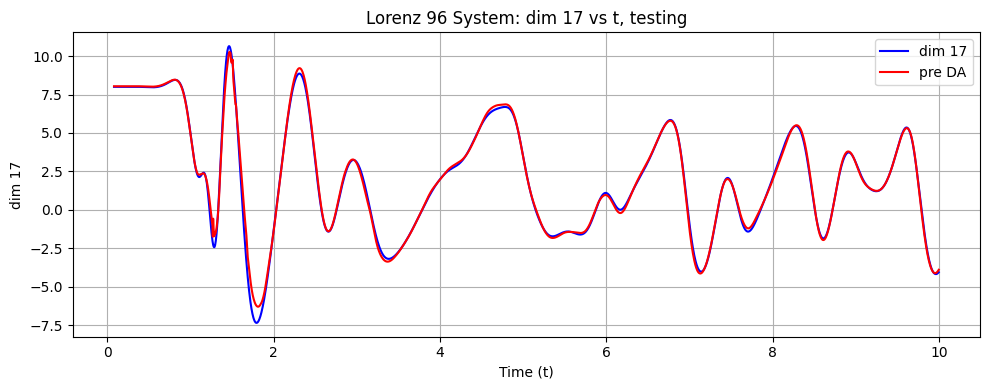

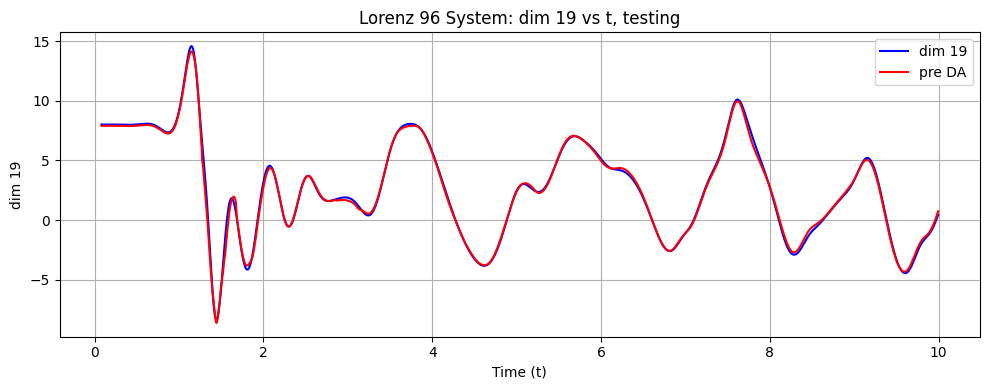

In [16]:
for i in range(dim_x):
    if_plot = np.random.randint(2)
    if if_plot:
        plt.figure(figsize = (10, 4))
        plt.plot(t[LSTM_seq_len: ], sol[LSTM_seq_len: , i], label = 'dim ' + str(i), color = 'blue')
        #plt.scatter(t[LSTM_seq_len: ], fifo_y[:, i], label = 'pre DA', color = 'red')
        plt.plot(t[LSTM_seq_len: ], fifo_y[:, i], label = 'pre DA', color = 'red')
        plt.title("Lorenz 96 System: dim " + str(i) + " vs t, testing")
        plt.xlabel("Time (t)")
        plt.ylabel("dim " + str(i))
        plt.grid(True)
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.show()

In [17]:
x_fifo = fifo_x[0].view(1, 20, dim_x)
y_fifo = []
for i in range(total_data_size - LSTM_seq_len):
    temp = model(x_fifo)
    y_fifo.append(copy.deepcopy(temp.view(-1).cpu().detach().numpy()))
    x_fifo = torch.cat((x_fifo[:, 1:, :], temp.view(1, 1, dim_x)), dim = 1)
    #x_fifo = torch.cat((x_fifo[:, 1:, :], copy.deepcopy(temp.view(1, 1, dim_x))), dim = 1)
y_fifo = np.array(y_fifo)

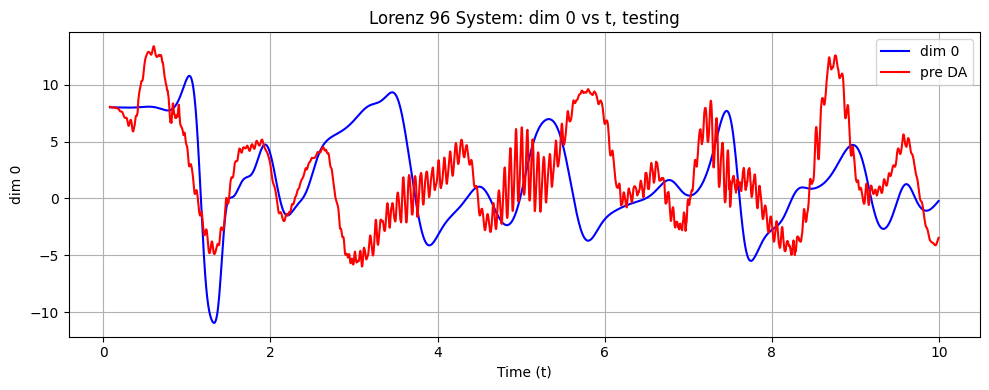

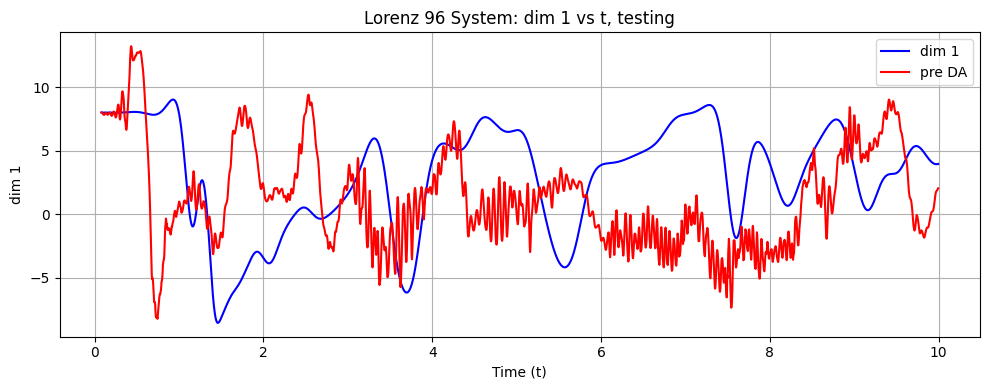

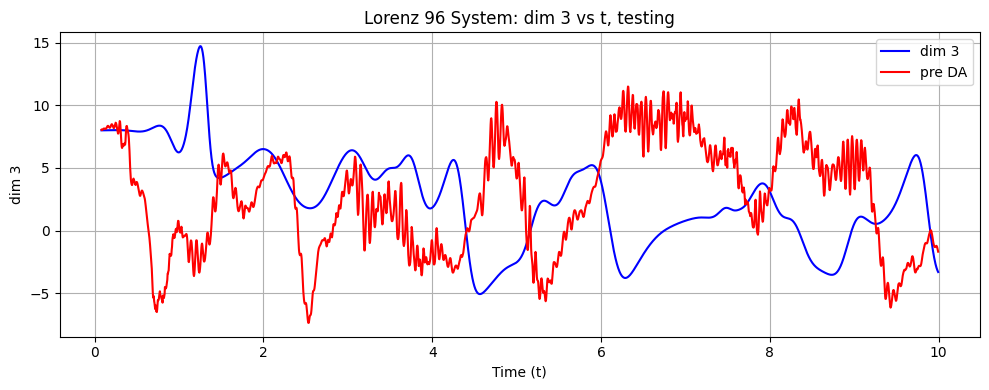

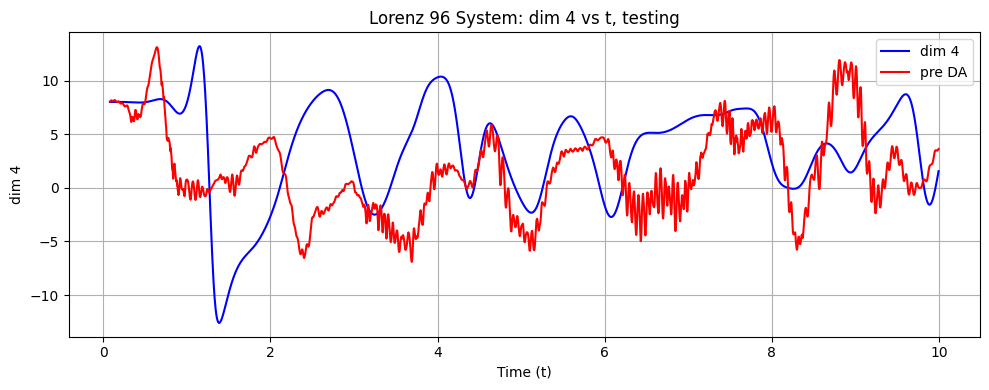

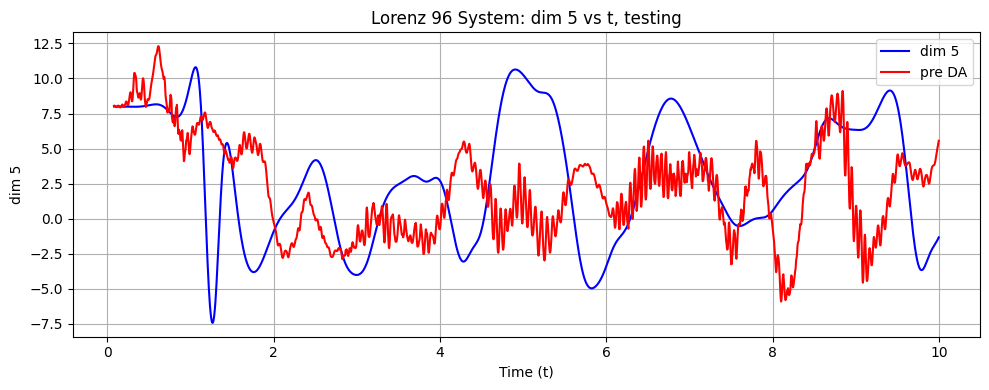

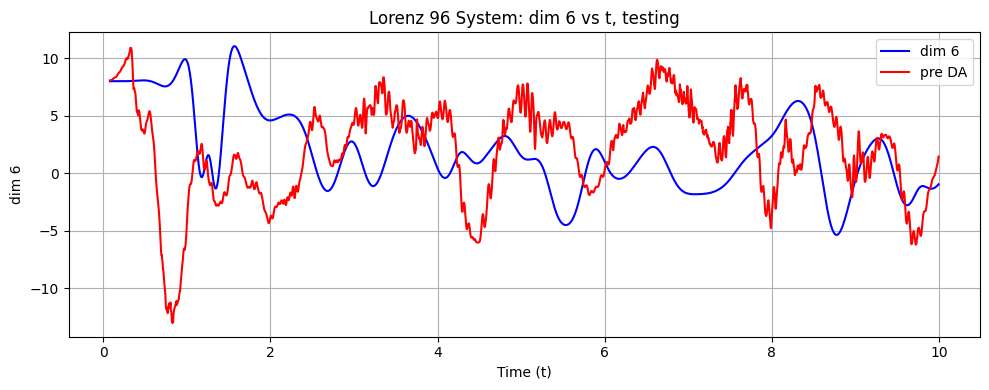

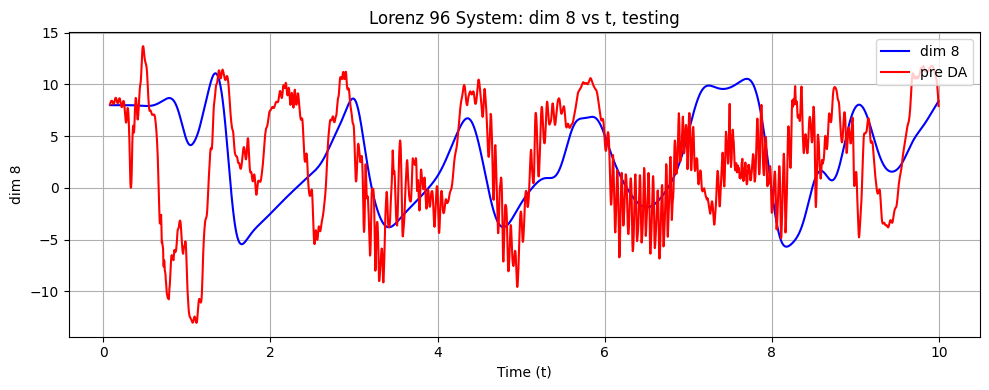

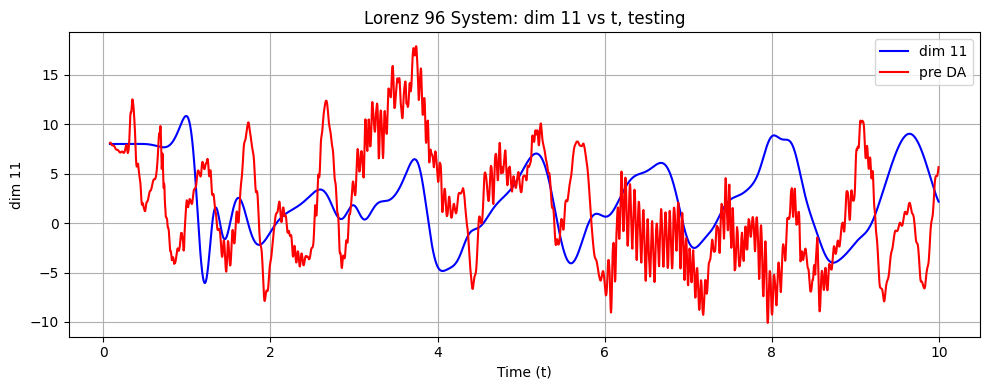

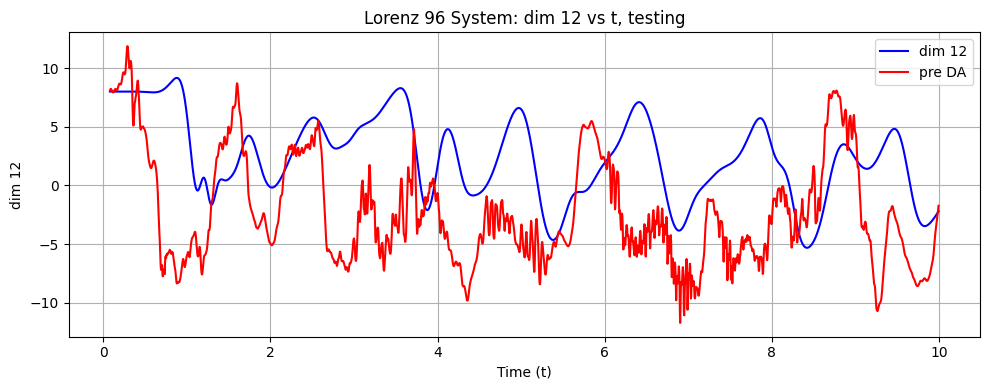

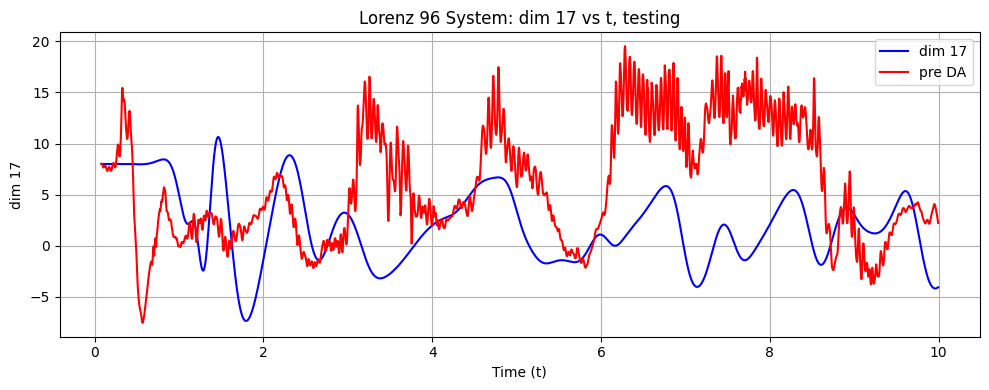

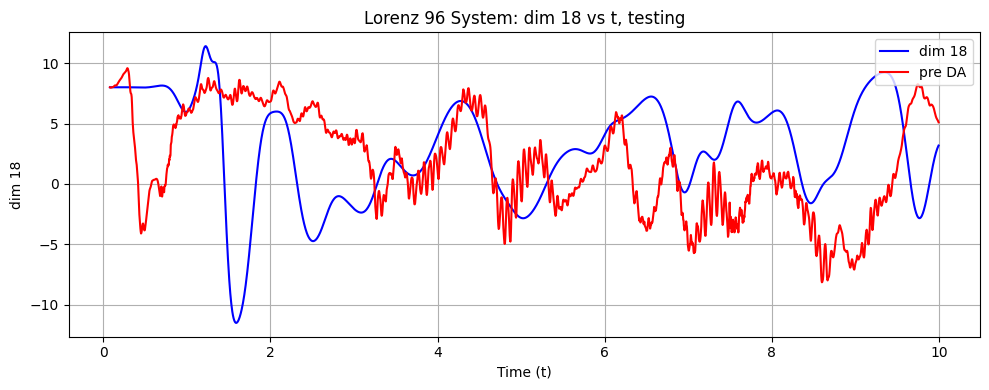

In [18]:
for i in range(dim_x):
    if_plot = np.random.randint(2)
    if if_plot:
        plt.figure(figsize = (10, 4))
        plt.plot(t[LSTM_seq_len: ], sol[LSTM_seq_len: , i], label = 'dim ' + str(i), color = 'blue')
        #plt.scatter(t[LSTM_seq_len: ], y_fifo[:, i], label = 'pre DA', color = 'red')
        plt.plot(t[LSTM_seq_len: ], y_fifo[:, i], label = 'pre DA', color = 'red')
        plt.title("Lorenz 96 System: dim " + str(i) + " vs t, testing")
        plt.xlabel("Time (t)")
        plt.ylabel("dim " + str(i))
        plt.grid(True)
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.show()

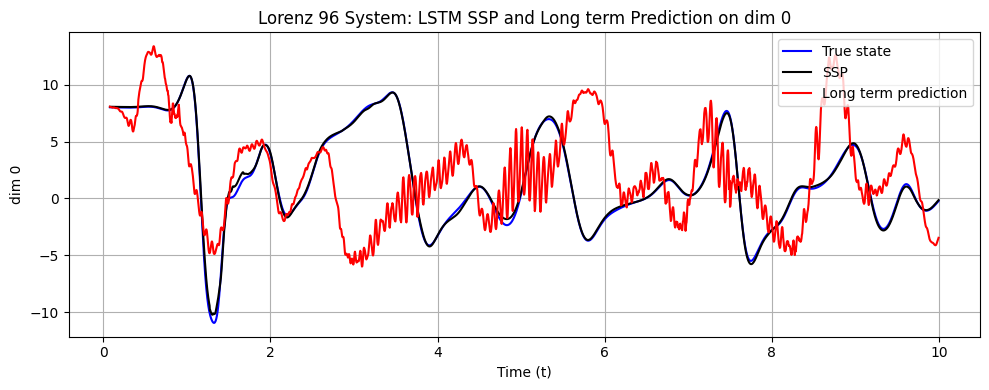

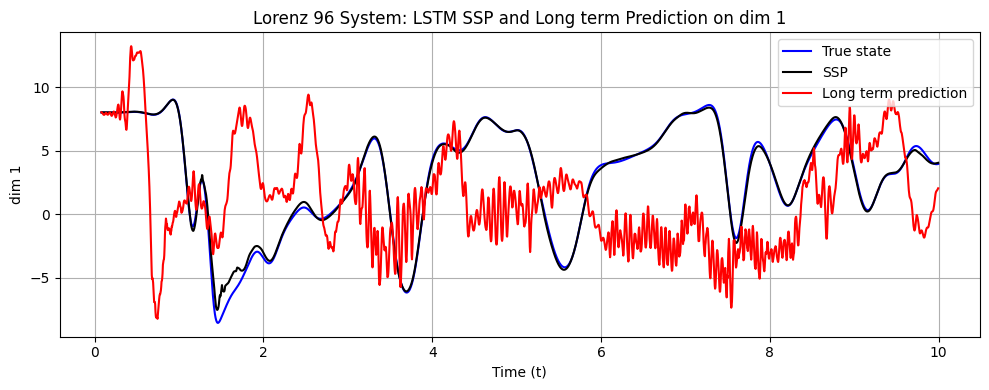

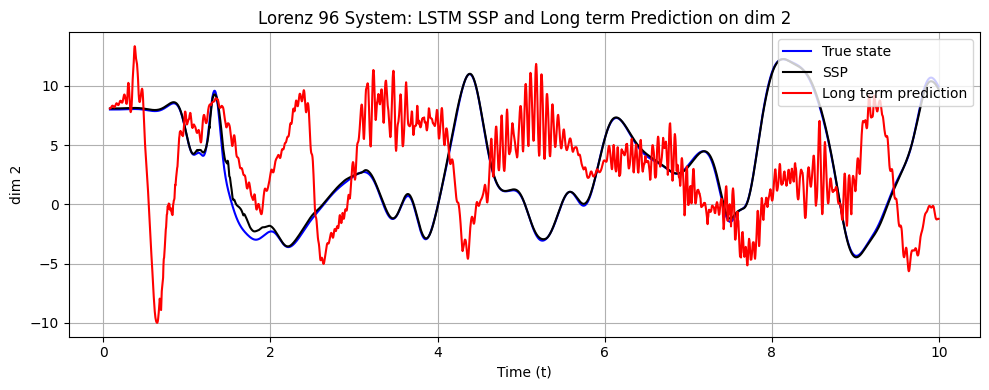

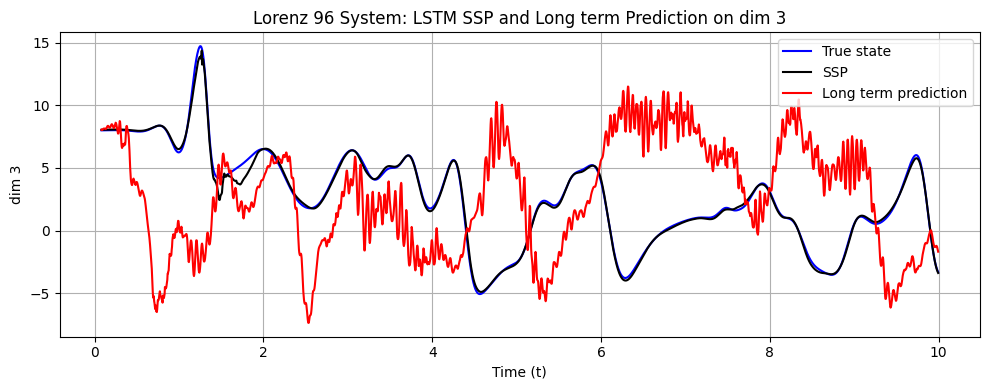

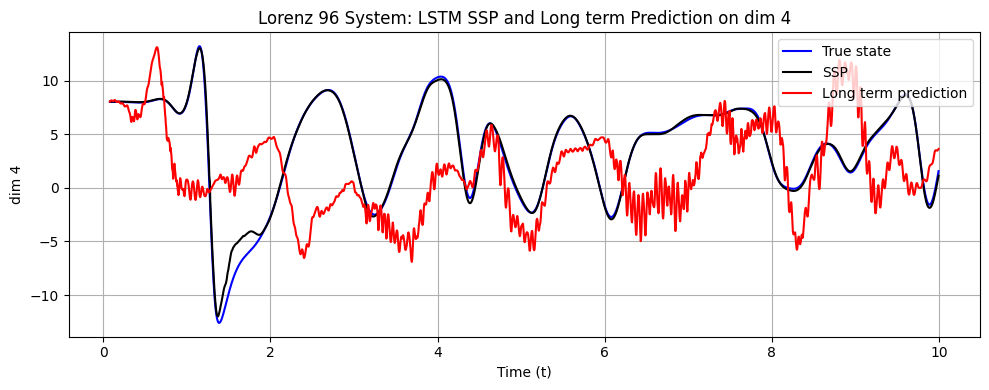

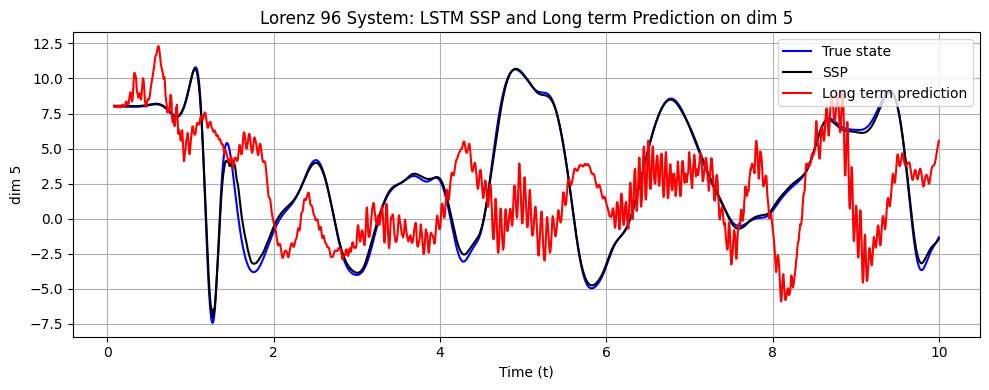

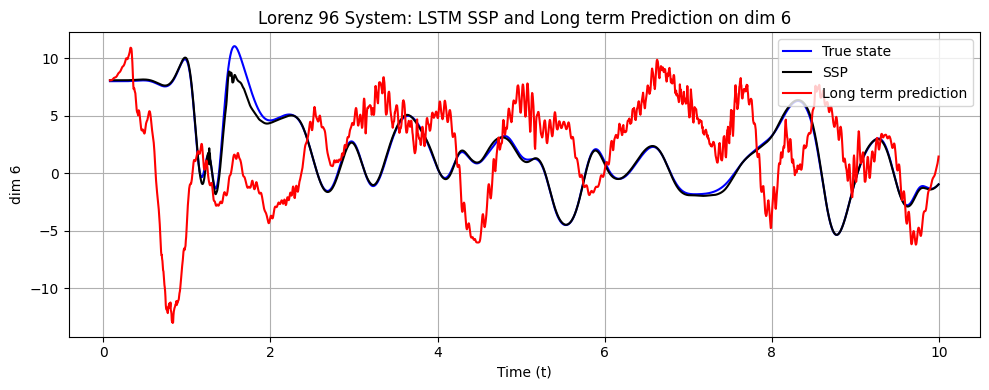

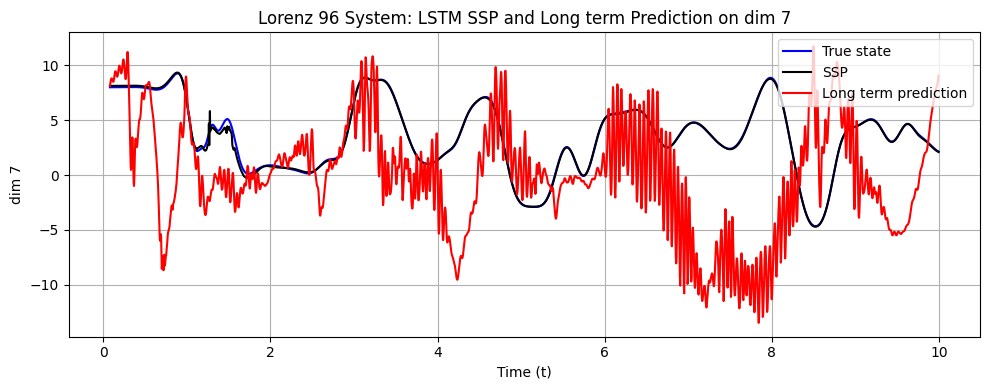

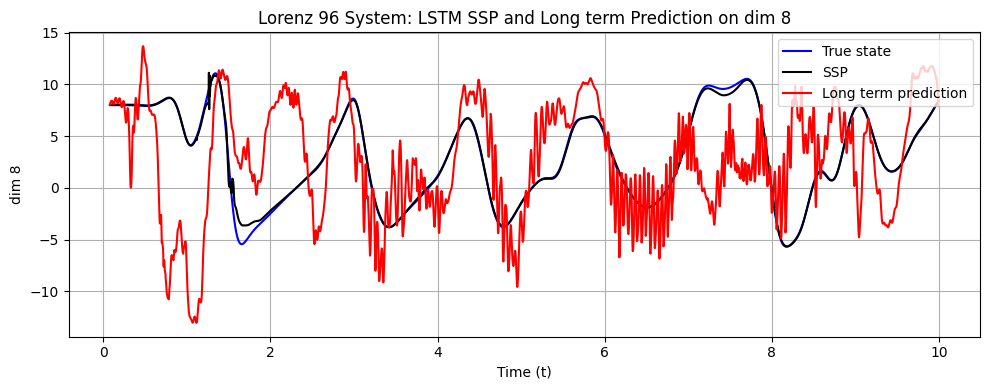

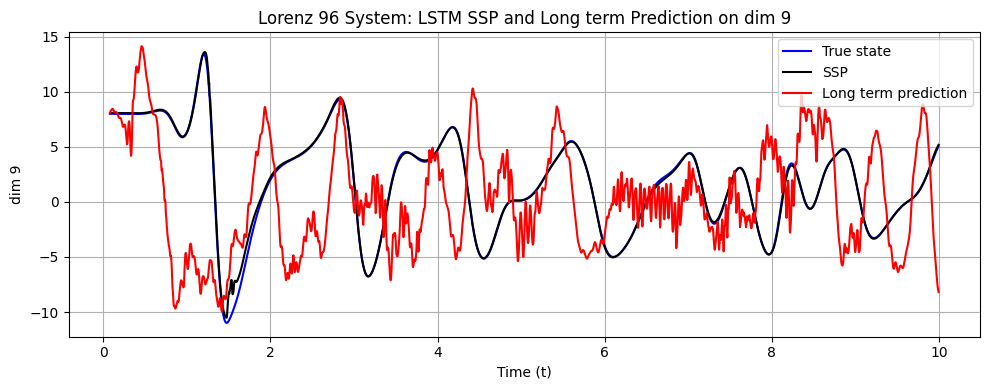

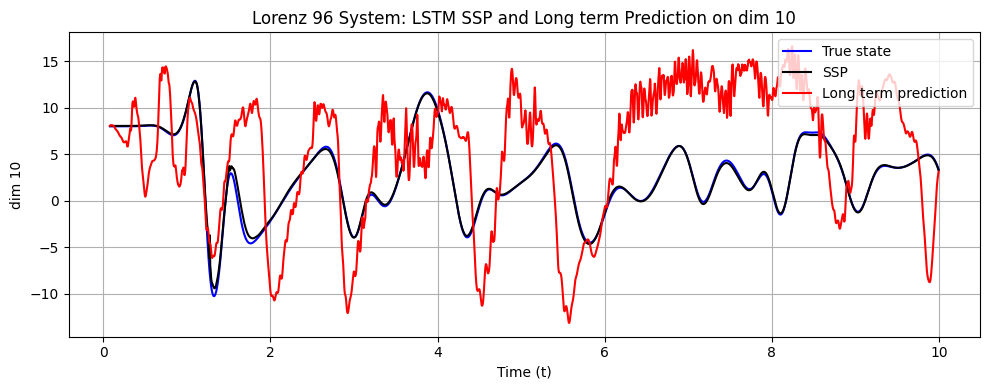

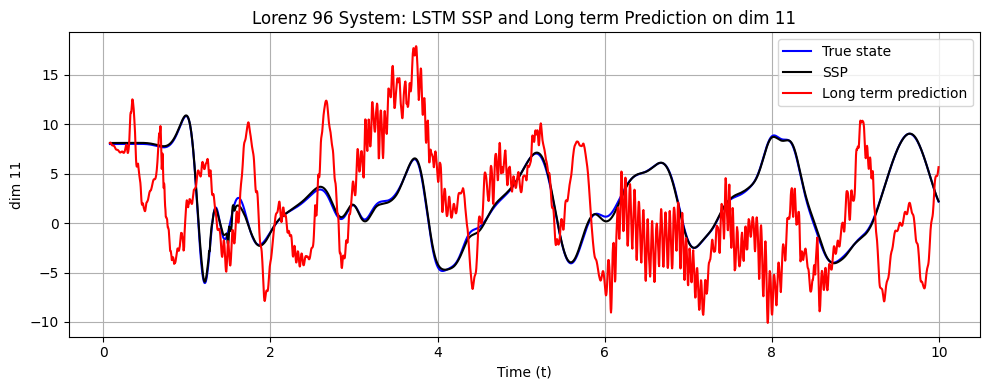

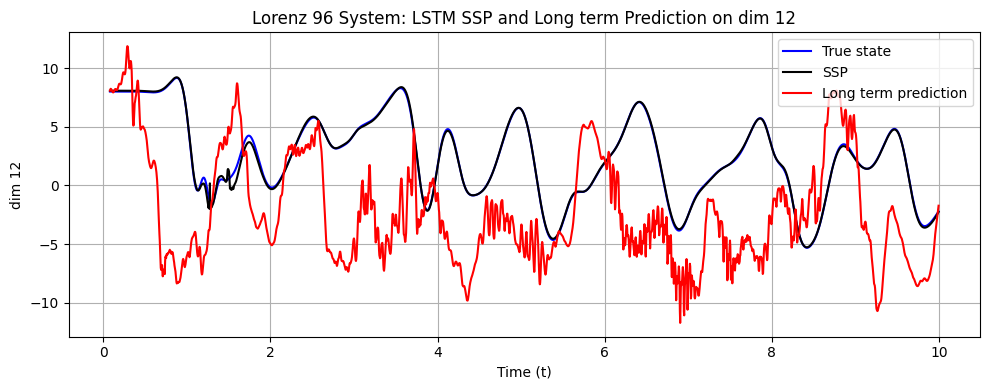

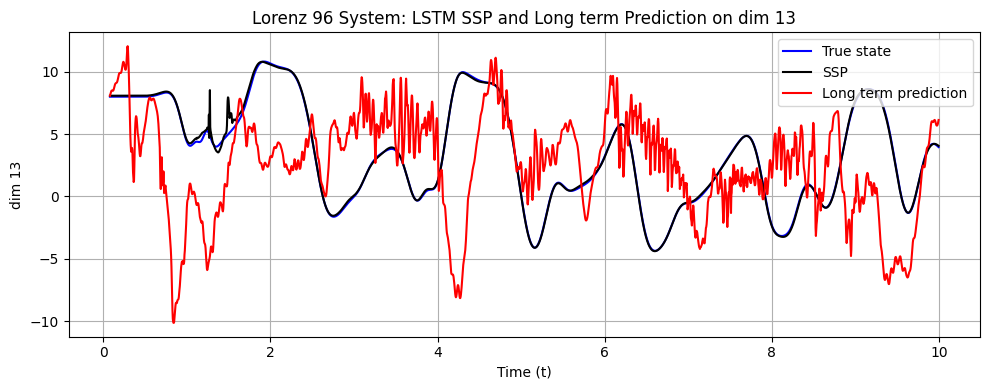

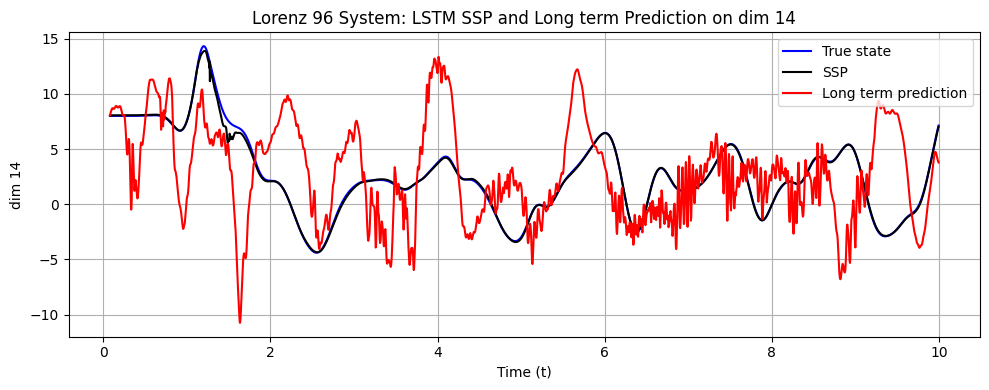

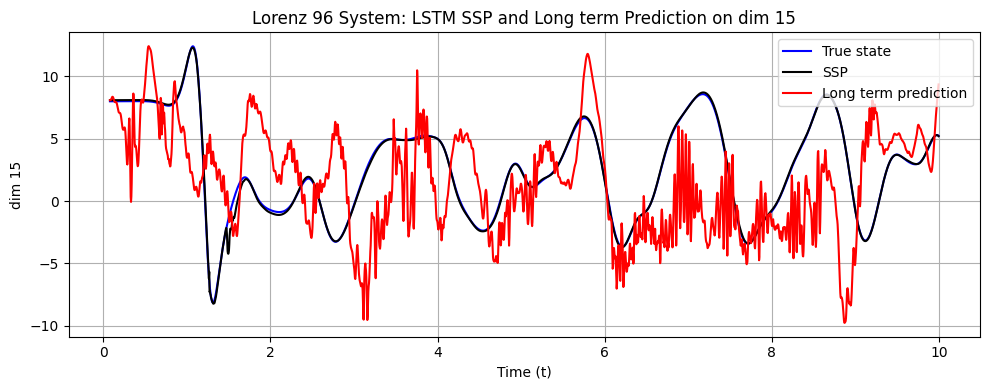

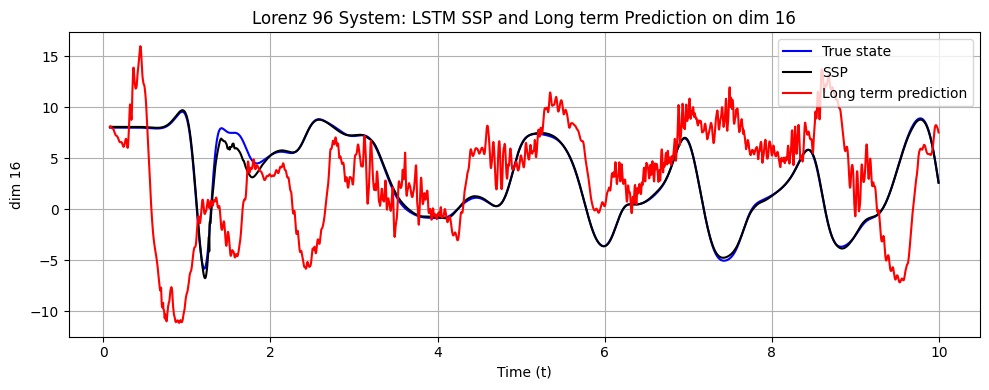

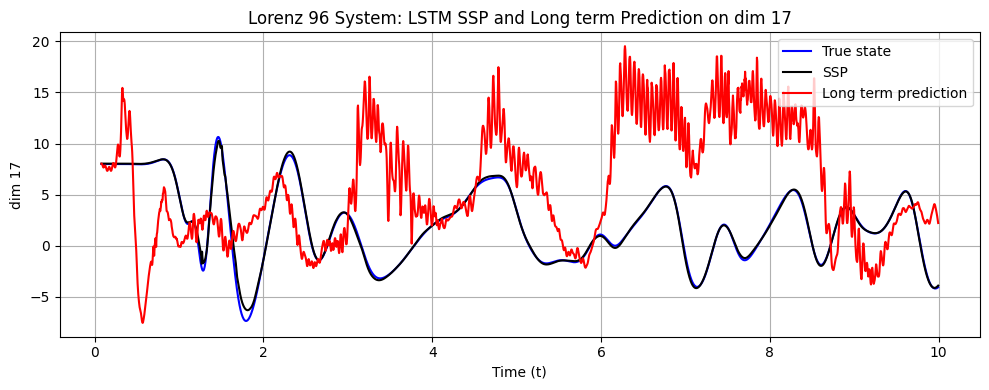

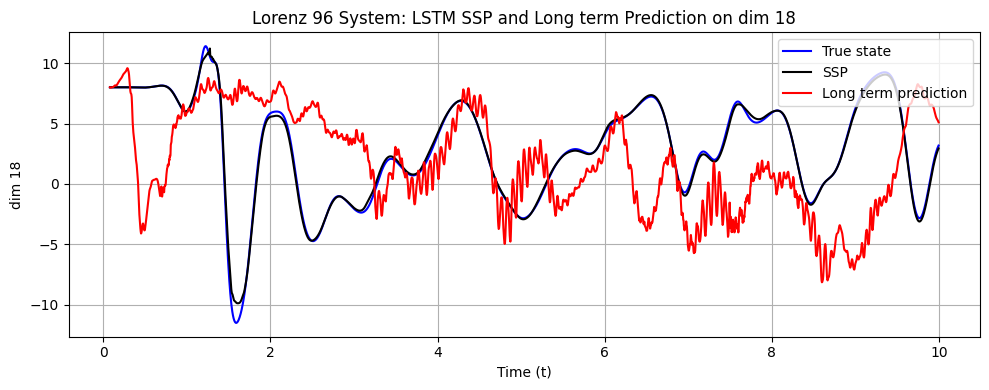

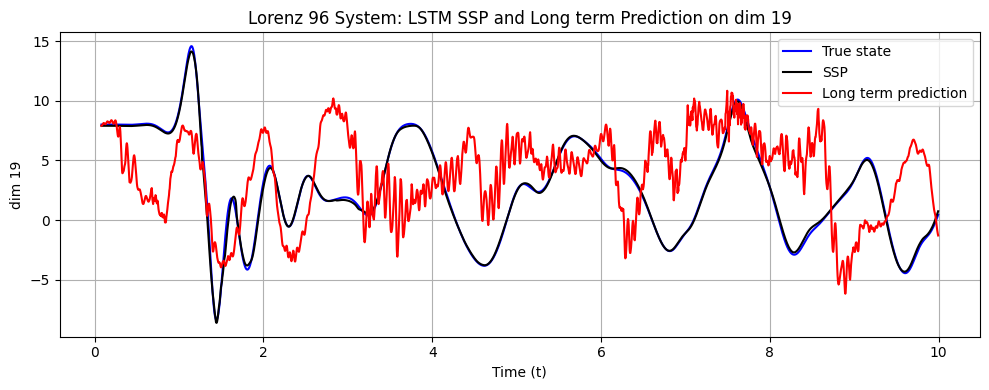

In [19]:
for i in range(dim_x):
    if_plot = 1#np.random.randint(2)
    if if_plot:
        plt.figure(figsize = (10, 4))
        plt.plot(t[LSTM_seq_len: ], sol[LSTM_seq_len: , i], label = 'True state', color = 'blue')
        #plt.scatter(t[LSTM_seq_len: ], y_fifo[:, i], label = 'pre DA', color = 'red')
        plt.plot(t[LSTM_seq_len: ], fifo_y[:, i], label = 'SSP', color = 'black')
        plt.plot(t[LSTM_seq_len: ], y_fifo[:, i], label = 'Long term prediction', color = 'red')
        plt.title("Lorenz 96 System: LSTM SSP and Long term Prediction on dim " + str(i))
        plt.xlabel("Time (t)")
        plt.ylabel("dim " + str(i))
        plt.grid(True)
        plt.legend(loc = "upper right")
        plt.tight_layout()
        #plt.savefig('LSTM_SSP_Long_term_dim_' + str(i) + '.png')
        plt.show()

In [20]:
loss_fn(torch.from_numpy(rr), torch.from_numpy(sol[LSTM_seq_len: , :])) # EnSF

tensor(0.3098, dtype=torch.float64)

In [21]:
loss_fn(torch.from_numpy(y_fifo), torch.from_numpy(sol[LSTM_seq_len: , :])) # FIFO only

tensor(39.4528, dtype=torch.float64)

In [22]:
loss_fn(torch.from_numpy(fifo_y), torch.from_numpy(sol[LSTM_seq_len: , :])) # LSTM with true input

tensor(0.0870, dtype=torch.float64)

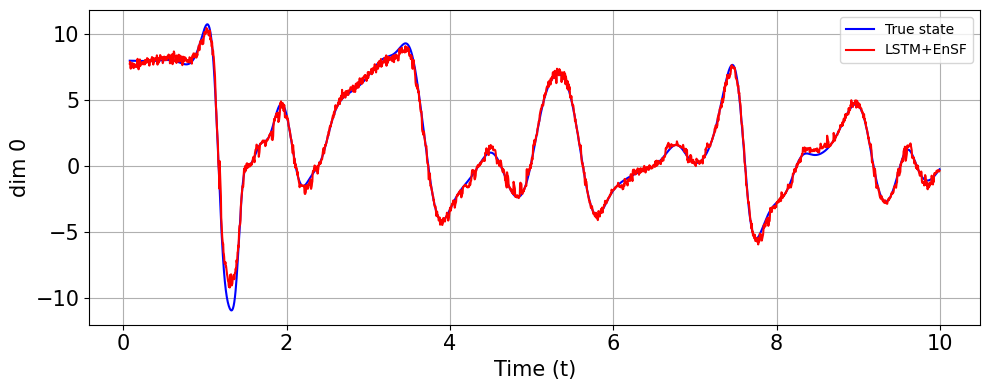

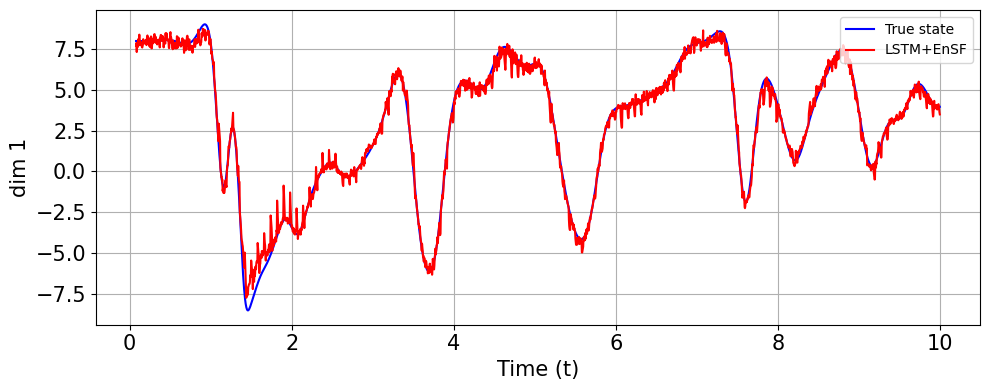

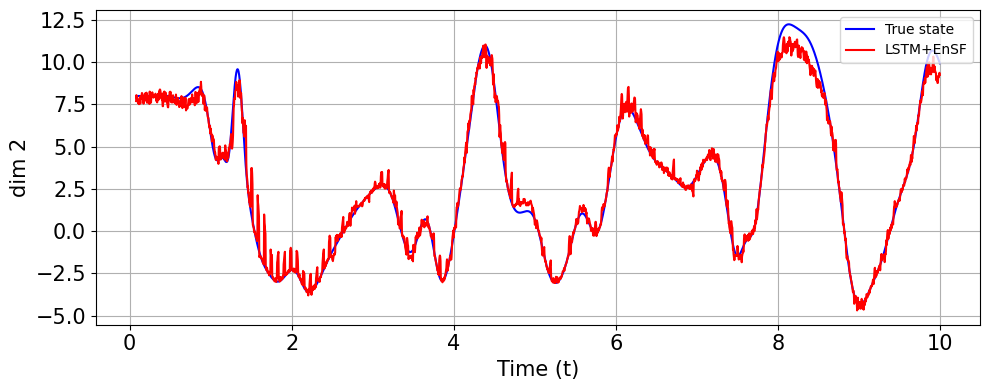

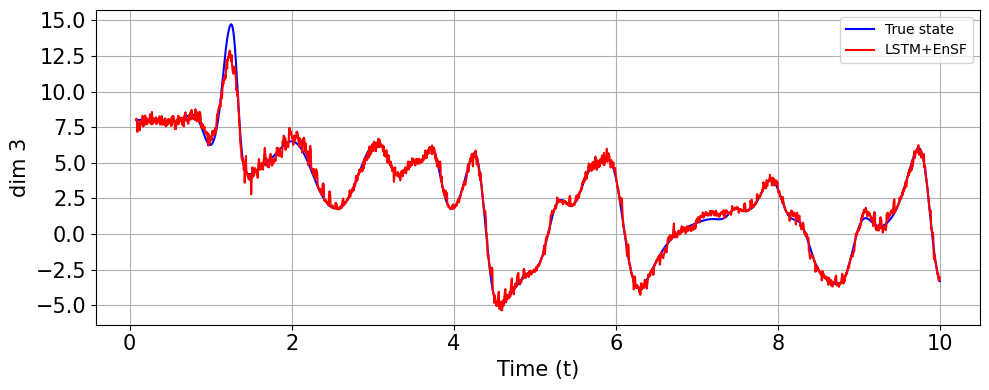

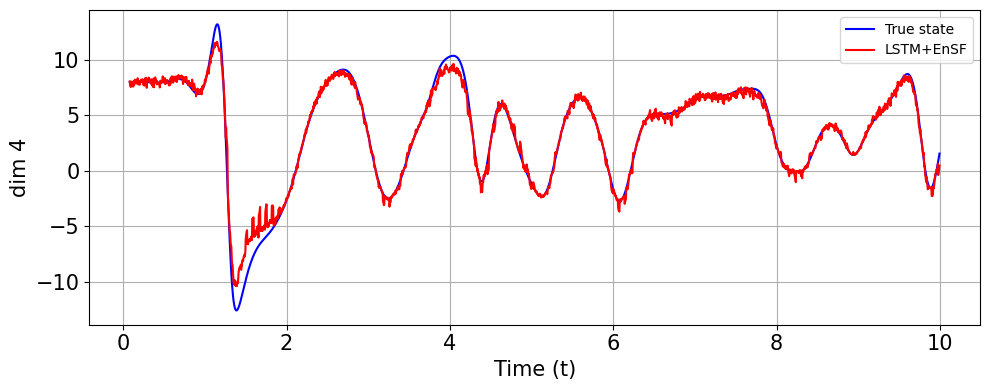

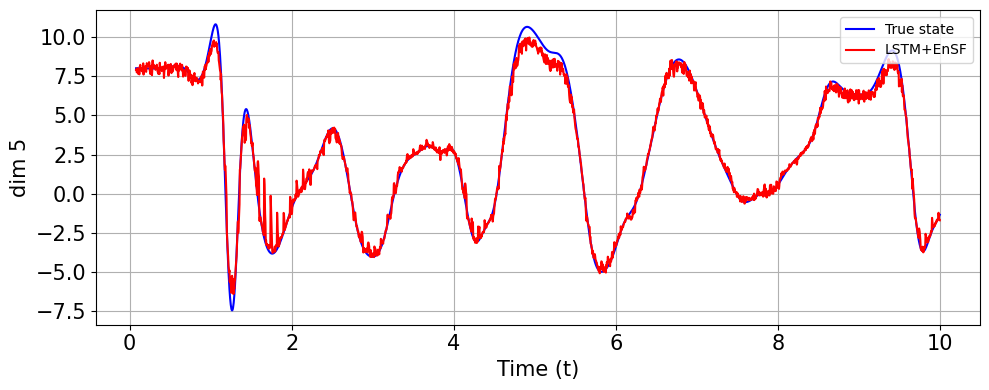

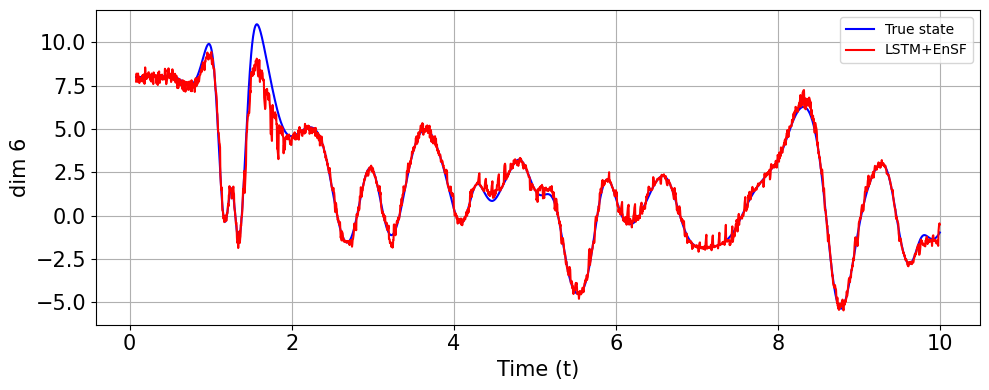

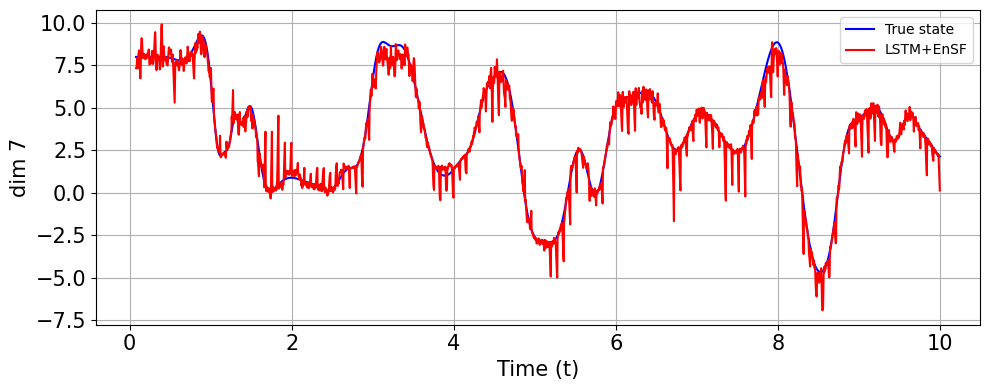

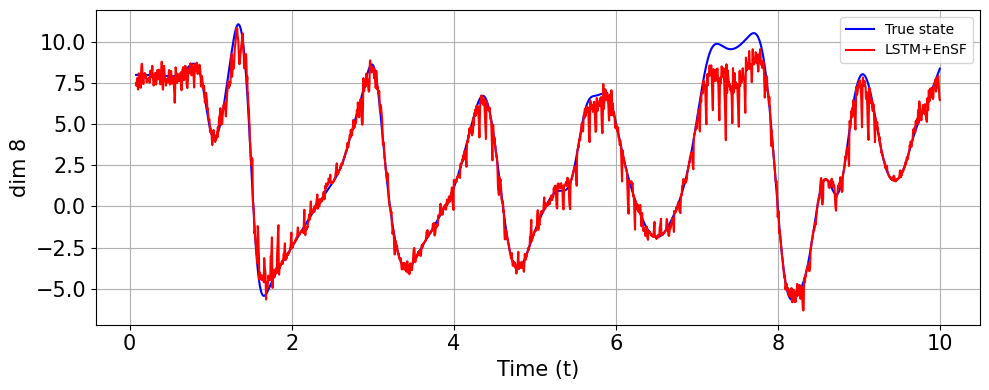

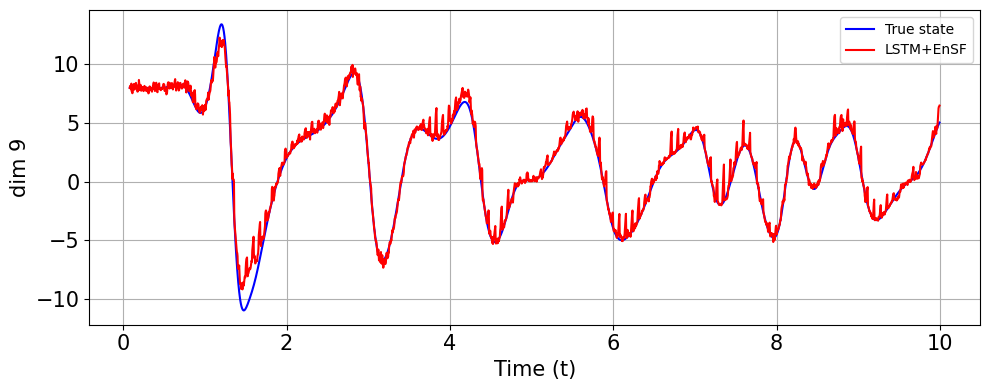

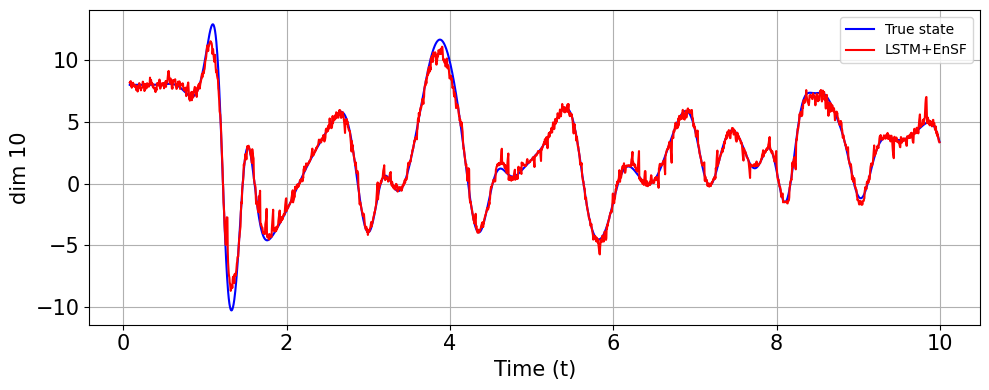

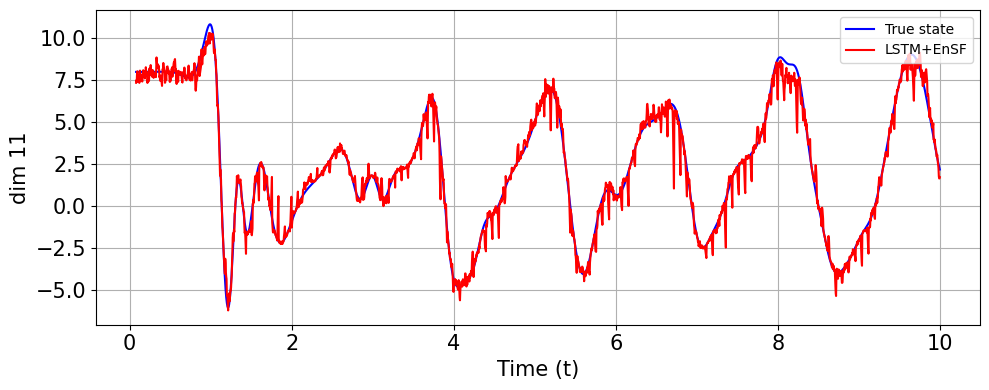

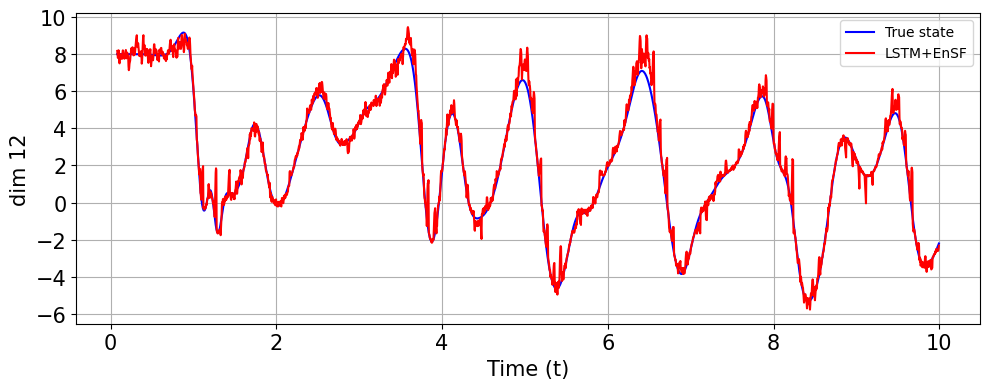

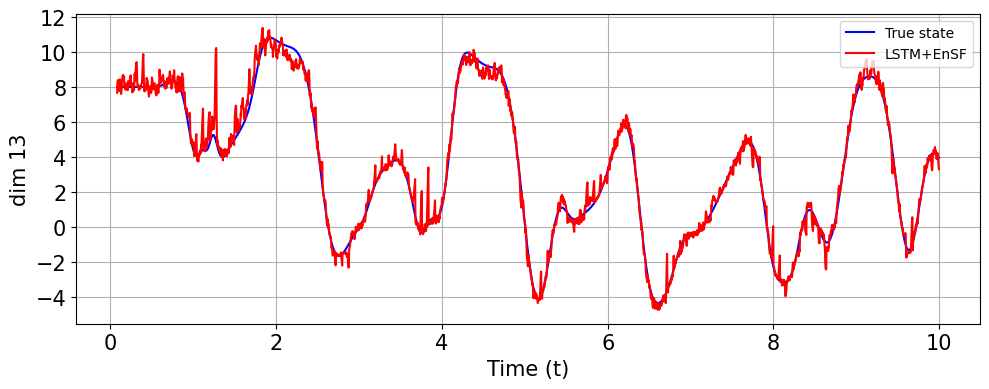

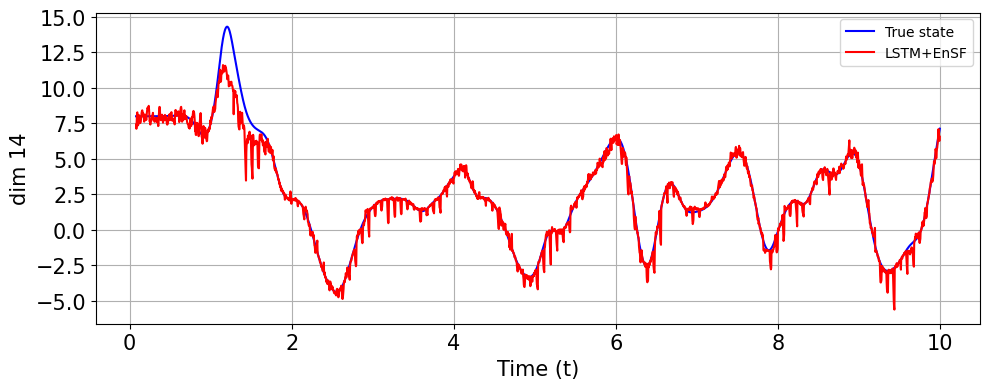

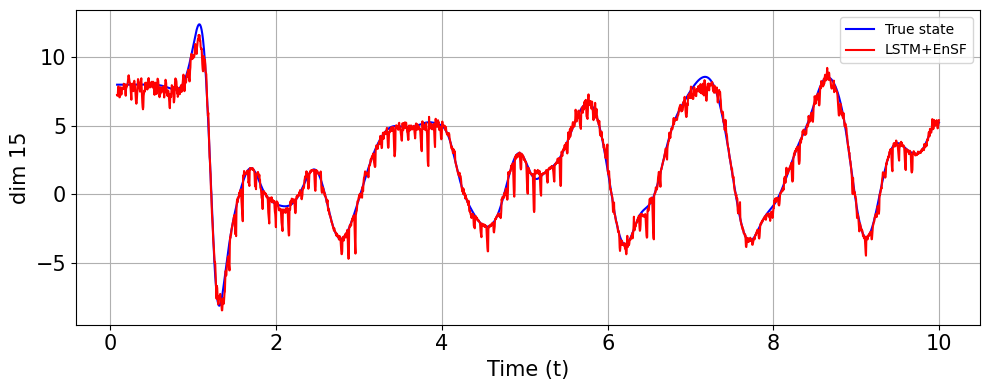

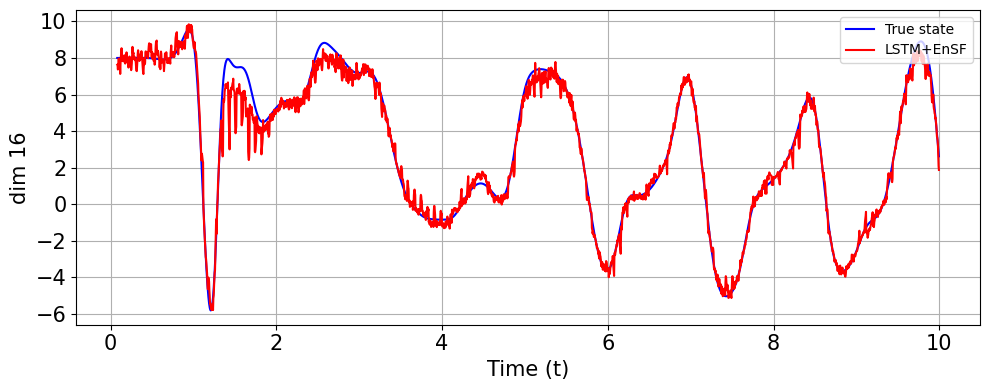

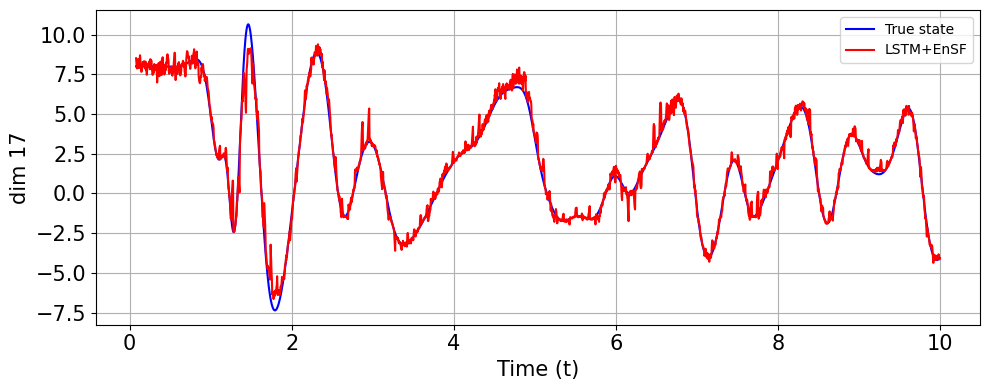

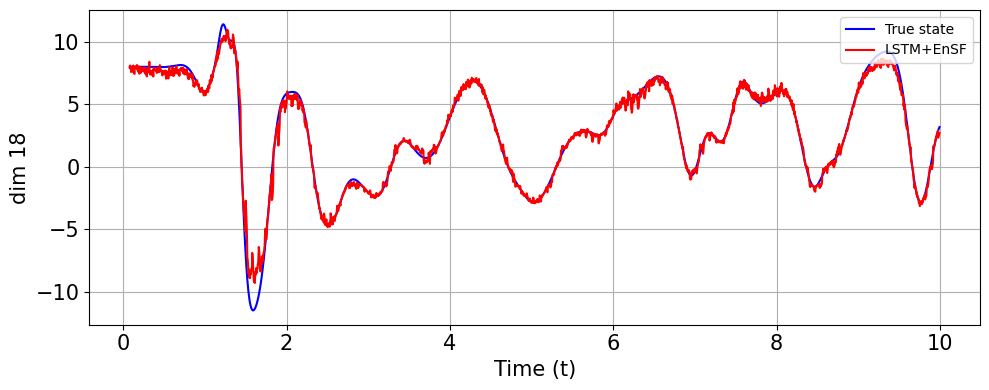

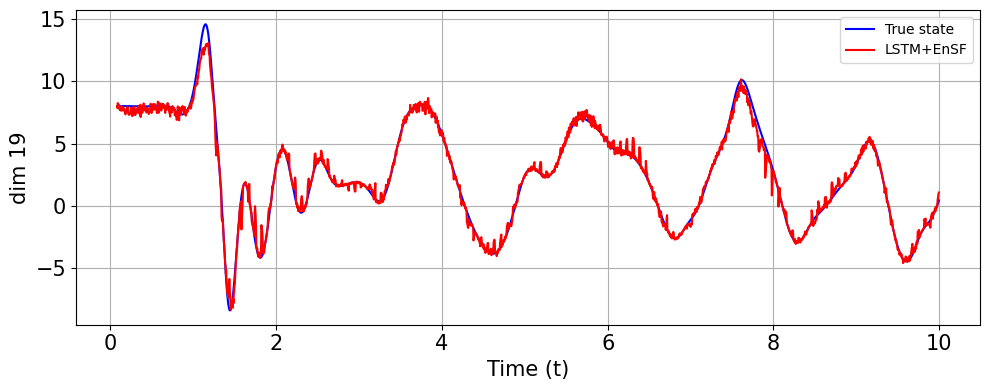

In [23]:
for i in range(dim_x):
    if_plot = 1#np.random.randint(2)
    if if_plot:
        plt.figure(figsize = (10, 4))
        plt.plot(t[LSTM_seq_len: ], sol[LSTM_seq_len: , i], label = 'True state', color = 'blue')
        #plt.scatter(t[LSTM_seq_len: ], y_fifo[:, i], label = 'pre DA', color = 'red')
        #plt.plot(t[LSTM_seq_len: ], fifo_y[:, i], label = 'LSTM with true data', color = 'black')
        plt.plot(t[LSTM_seq_len: ], rr[:, i], label = 'LSTM+EnSF', color = 'red')
        #plt.title("Lorenz 96 System: dim " + str(i) + " vs t, testing")
        plt.xlabel("Time (t)", fontsize = 15)
        plt.xticks(fontsize = 15)
        plt.ylabel("dim " + str(i), fontsize = 15)
        plt.yticks(fontsize = 15)
        plt.grid(True)
        plt.legend(loc = "upper right")
        plt.tight_layout()
        #plt.savefig('LSTM_Lorenz96_SA_plot/LSTM_Lorenz96_SA_EnSF_dim_' + str(i) + '.png')
        plt.show()

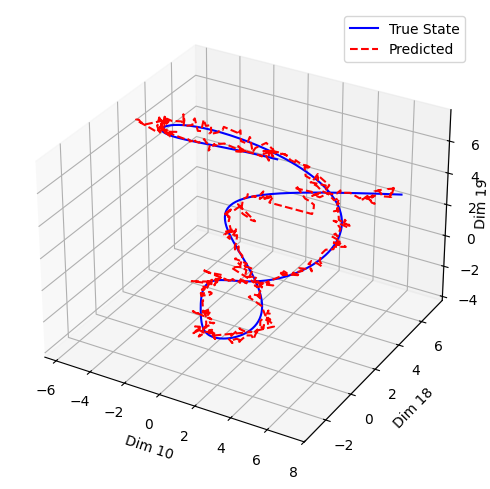

In [24]:
plot_start = 1000
plot_end = 1500
plot_dim1 = 10
plot_dim2 = 18
plot_dim3 = 19
ax_3D = plt.figure(figsize = (10, 6)).add_subplot(projection = '3d')
ax_3D.plot(sol[LSTM_seq_len + plot_start: plot_end + LSTM_seq_len, plot_dim1], 
           sol[LSTM_seq_len + plot_start: plot_end + LSTM_seq_len, plot_dim2], 
           sol[LSTM_seq_len + plot_start: plot_end + LSTM_seq_len, plot_dim3], label = 'True State', color = 'blue')
ax_3D.plot(rr[plot_start: plot_end, plot_dim1], 
           rr[plot_start: plot_end, plot_dim2], 
           rr[plot_start: plot_end, plot_dim3], label = 'Predicted', color = 'red', linestyle = 'dashed')
ax_3D.legend()
ax_3D.set_xlabel('Dim 10')
ax_3D.set_ylabel('Dim 18')
ax_3D.set_zlabel('Dim 19')
ax_3D.zaxis.labelpad=-5
#bbox = ax_3D.bbox_inches.from_bounds(3, 0.7, 4.7, 4.6)
#plt.savefig('LSTM_Lorenz96_SA_plot/LSTM_Lorenz96_SA_EnSF_3D.png', bbox_inches=bbox)
plt.show()

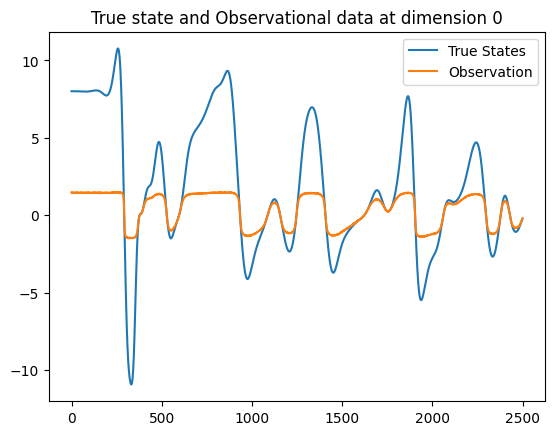

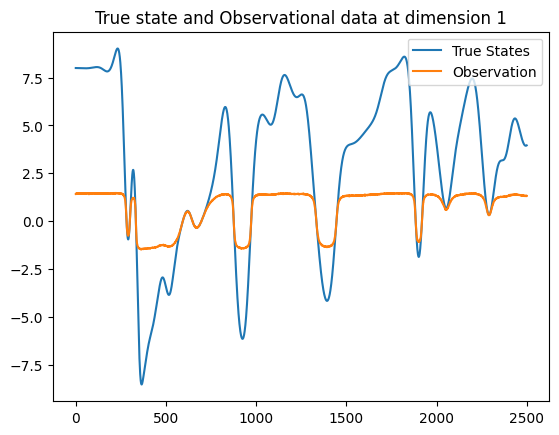

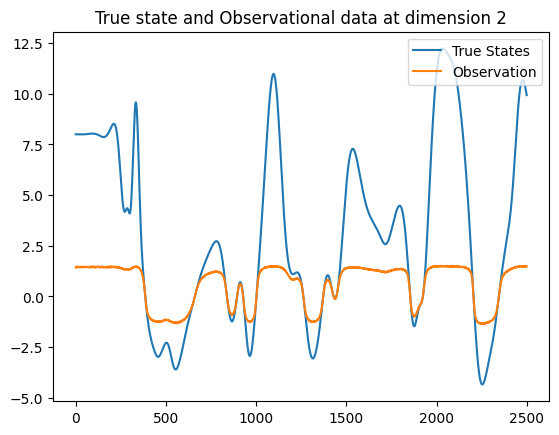

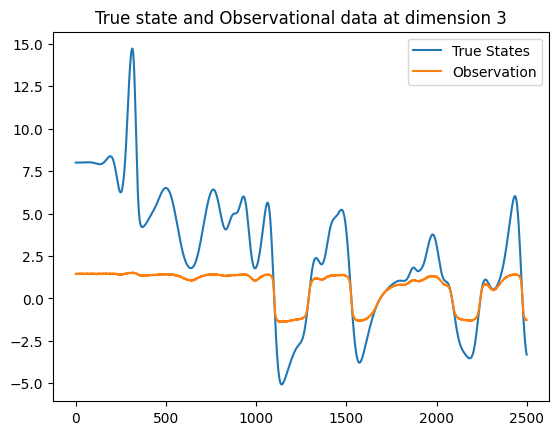

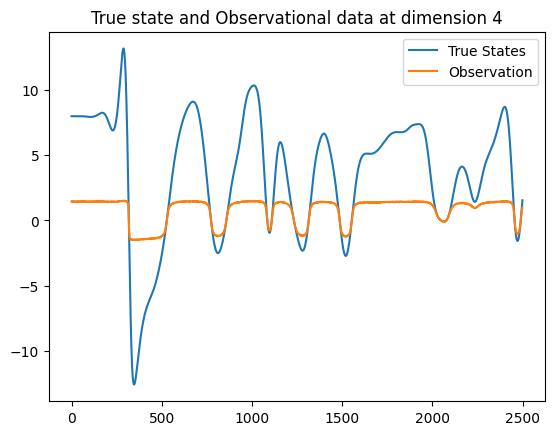

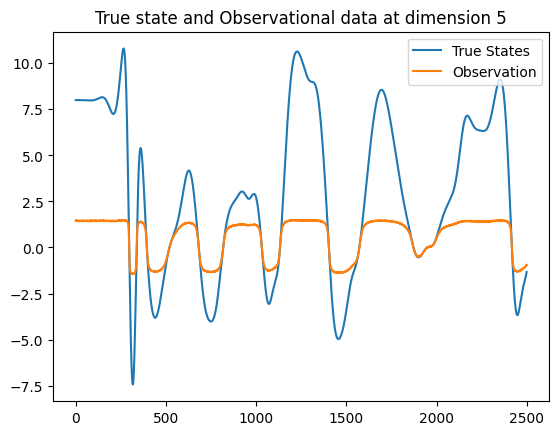

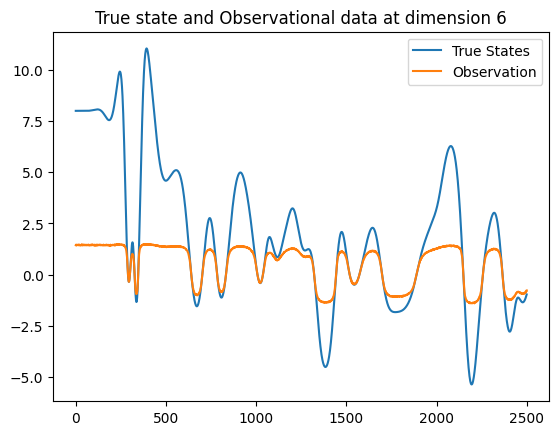

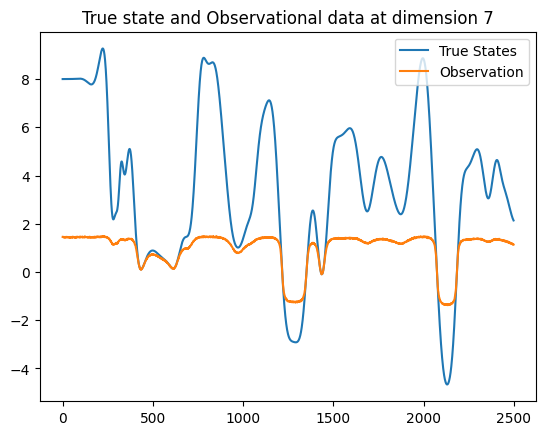

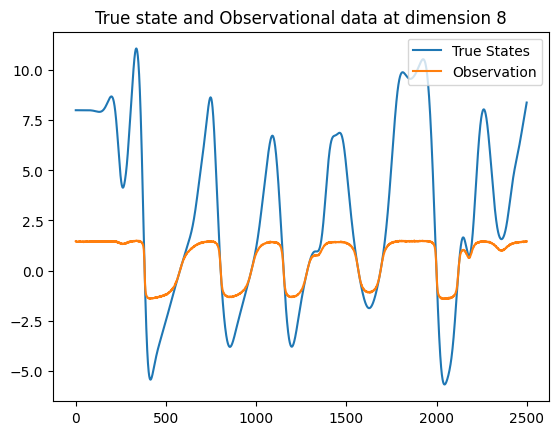

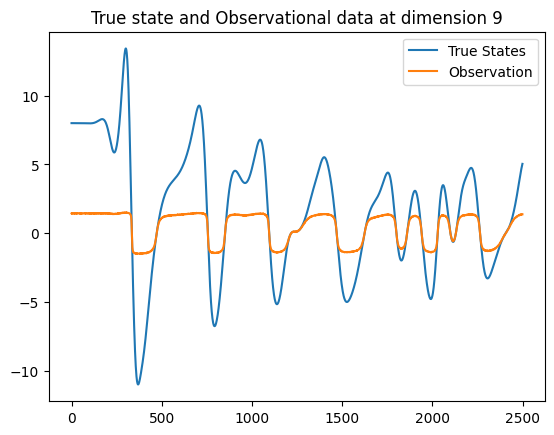

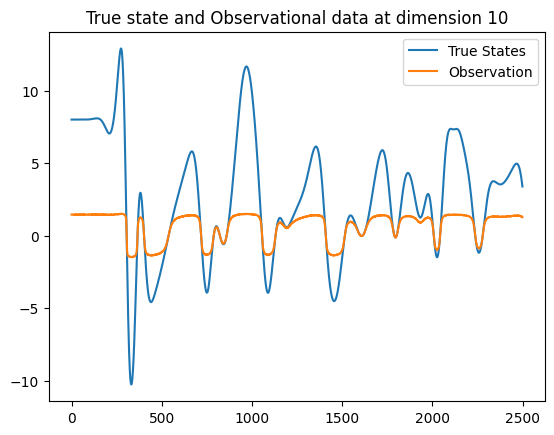

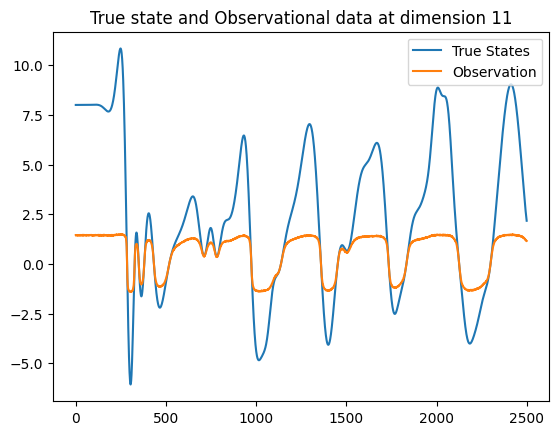

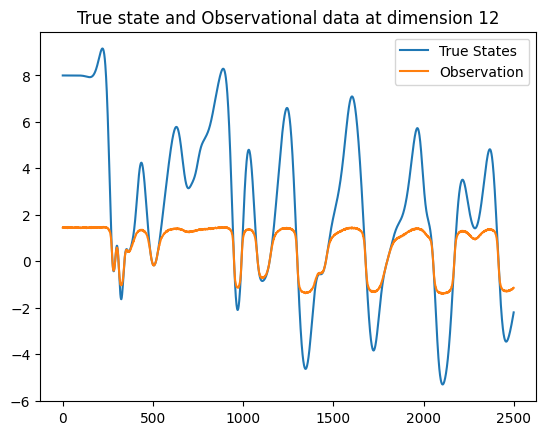

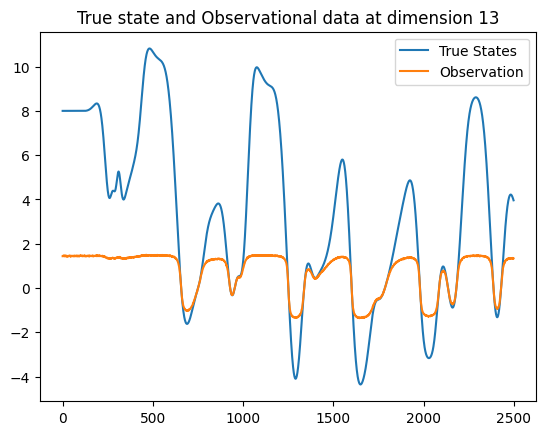

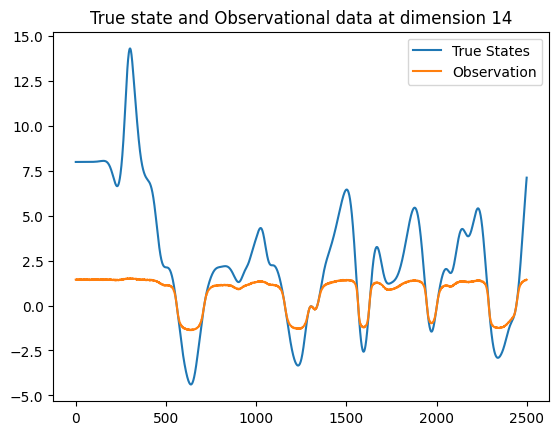

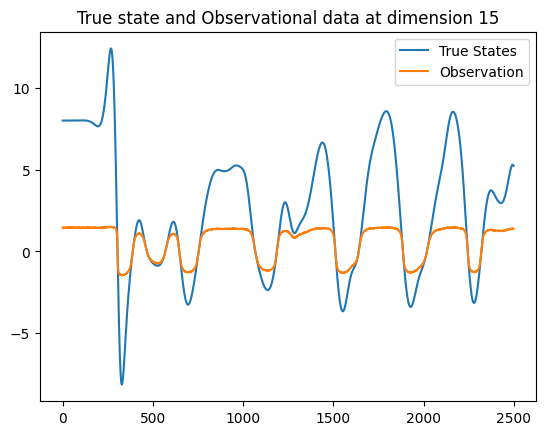

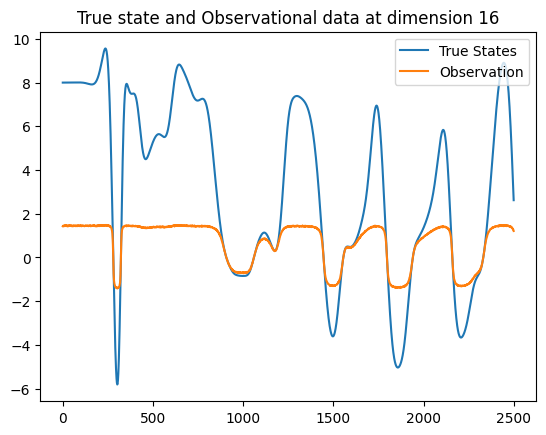

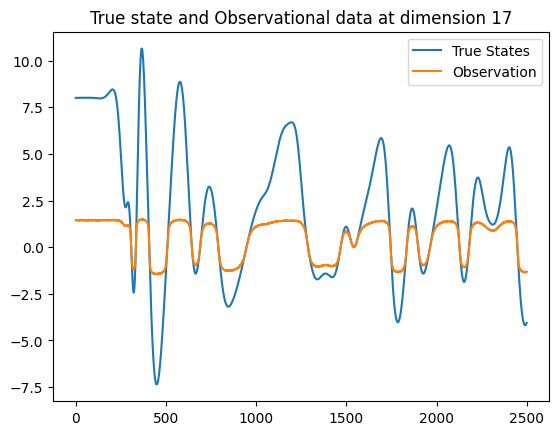

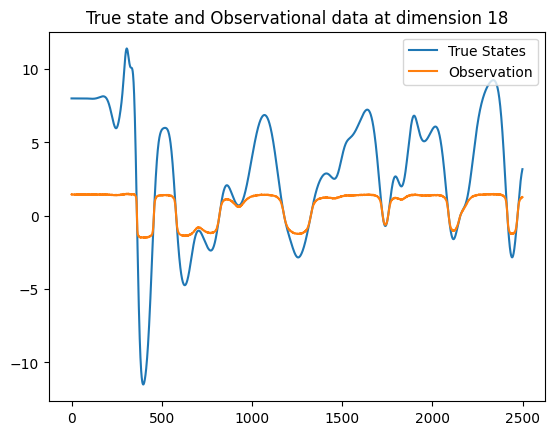

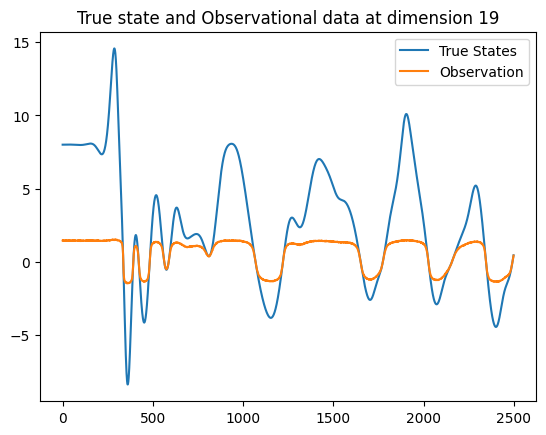

In [25]:
for i in range(20):
    plt.plot(np.arange(2500), sol[:, i], label = 'True States')
    plt.plot(np.arange(2500), np.atan(sol[:, i]) + np.random.normal(0, 0.01, size = sol[:, i].shape), label = 'Observation')
    plt.legend(loc = 'upper right')
    plt.title('True state and Observational data at dimension ' + str(i))
    #plt.savefig('LSTM_Lorenz96_Arctan/dim_' + str(i) + '.png')
    plt.show()

In [26]:
mse_all_step = np.array(mse_all_step)

In [27]:
df = pd.DataFrame({'MSE': mse_all_step})
#df.to_csv('LSTM_SA_1.csv', index = False)
#pd.DataFrame({'MSE': np.square(fifo_y - sol[LSTM_seq_len: ]).mean(axis = 1)}).to_csv('LSTM_SA_SSP_1.csv', index = False)
#pd.DataFrame({'MSE': np.square(y_fifo - sol[LSTM_seq_len: ]).mean(axis = 1)}).to_csv('LSTM_SA_PF_1.csv', index = False)

In [28]:
x_states = np.array(x_states)

In [29]:
np.square(x_states - sol[20: ])

array([[4.84570408e-02, 8.18754790e-02, 8.97732658e-02, ...,
        2.61221703e-01, 6.88939038e-03, 1.02698022e-03],
       [6.37783739e-03, 1.34241880e-02, 2.50078038e-03, ...,
        6.72389791e-02, 1.10689871e-02, 2.56878285e-02],
       [2.32337102e-01, 4.56143900e-01, 1.07184193e-02, ...,
        2.80547742e-03, 1.30664702e-02, 6.01279673e-02],
       ...,
       [4.02173396e-03, 1.97755035e-02, 5.11490173e-01, ...,
        1.35151849e-02, 2.70599616e-01, 3.19101157e-01],
       [1.84023715e-02, 1.17178984e-01, 3.83849969e-01, ...,
        3.62140188e-03, 2.57662354e-01, 4.12191442e-01],
       [1.21096688e-02, 2.16900188e-01, 4.82473808e-01, ...,
        5.22886564e-05, 2.17797143e-01, 4.08363095e-01]], shape=(2480, 20))